##Team components:

*   888573 - OMAR DEGUI
*   881345 - LORENZO LUCHESINI
*   883831 - MATTEO RIGONI



# Unsupervised Learning Project - Heart Disease Dataset

**Goal.** Discover clusters in the UCI Heart Disease dataset (920 samples) using a fully **unsupervised** pipeline, and explore the probabilistic relationships among the clinical variables with a **Bayesian Network**.

| Stage | Technique |
|-------|-----------|
| Pre-processing | median/mode imputation, drop > 50 % missing, one-hot encoding, `StandardScaler`, `IsolationForest` outlier removal |
| Dimensionality reduction | `PCA` (90 % variance) + `t-SNE` for 2-D visualisation |
| Clustering (>= 3) | **K-means++**, **Agglomerative (Ward)**, **DBSCAN** |
| Internal validation | **Silhouette**, Davies-Bouldin|
| Probabilistic model | **Bayesian Network** - Hill-Climb structure search scored by **BIC / AIC** |


## 1. Environment setup

In [1]:
!pip -q install yellowbrick kneed pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 6.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform

from yellowbrick.cluster import KElbowVisualizer
from kneed import KneeLocator

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PAL = ['black', 'red', 'green', 'blue', 'orange',
       'purple', 'magenta', 'cyan', 'brown', 'olive']
sns.set_style("whitegrid")

## 2. Data loading
Upload `heart_disease.csv` (or mount Google Drive) and adjust `FILE_PATH`.

In [3]:
FILE_PATH = "heart_disease.csv"
df = pd.read_csv(FILE_PATH)
N, M = df.shape
print(f"The dataset has {N} objects and {M} attributes.")
print(f"Total missing values: {df.isnull().sum().sum()}")
df.head()

The dataset has 920 objects and 15 attributes.
Total missing values: 1759


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


## 3. Exploratory data analysis
Inspect dtypes, per-column missingness and distributions before deciding the cleaning strategy.

In [4]:
print("Schema and non-null counts:")
df.info()

print("\nUnique values per column:")
for col in df.columns:
    n = df[col].nunique()
    extra = f"  ->  {sorted(map(str, df[col].dropna().unique()))}" if n <= 6 else ""
    print(f"  {col:<10} {n:>4} unique{extra}")

Schema and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB

Unique values per column:
  id          920 unique
  age          50 unique
  sex           2 unique  ->  ['Female', 'Male']
  dataset     

Missing-value ratio per column:
ca          66.4 %
thal        52.8 %
slope       33.6 %
fbs          9.8 %
oldpeak      6.7 %
trestbps     6.4 %
thalch       6.0 %
exang        6.0 %
chol         3.3 %
restecg      0.2 %
dataset      0.0 %
id           0.0 %
cp           0.0 %
age          0.0 %
sex          0.0 %
dtype: object


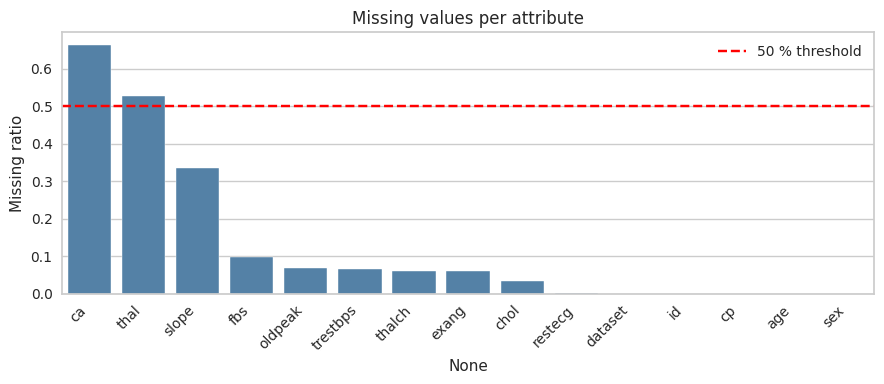

In [5]:
# Missing-value ratio per column (sorted) - drives the cleaning decisions below.
missing_ratio = df.isnull().mean().sort_values(ascending=False)
print("Missing-value ratio per column:")
print((missing_ratio * 100).round(1).astype(str) + " %")

plt.figure(figsize=(9, 4))
sns.barplot(x=missing_ratio.index, y=missing_ratio.values, color="steelblue")
plt.axhline(0.5, color="red", ls="--", label="50 % threshold")
plt.xticks(rotation=45, ha="right"); plt.ylabel("Missing ratio")
plt.title("Missing values per attribute"); plt.legend()
plt.tight_layout(); plt.show()

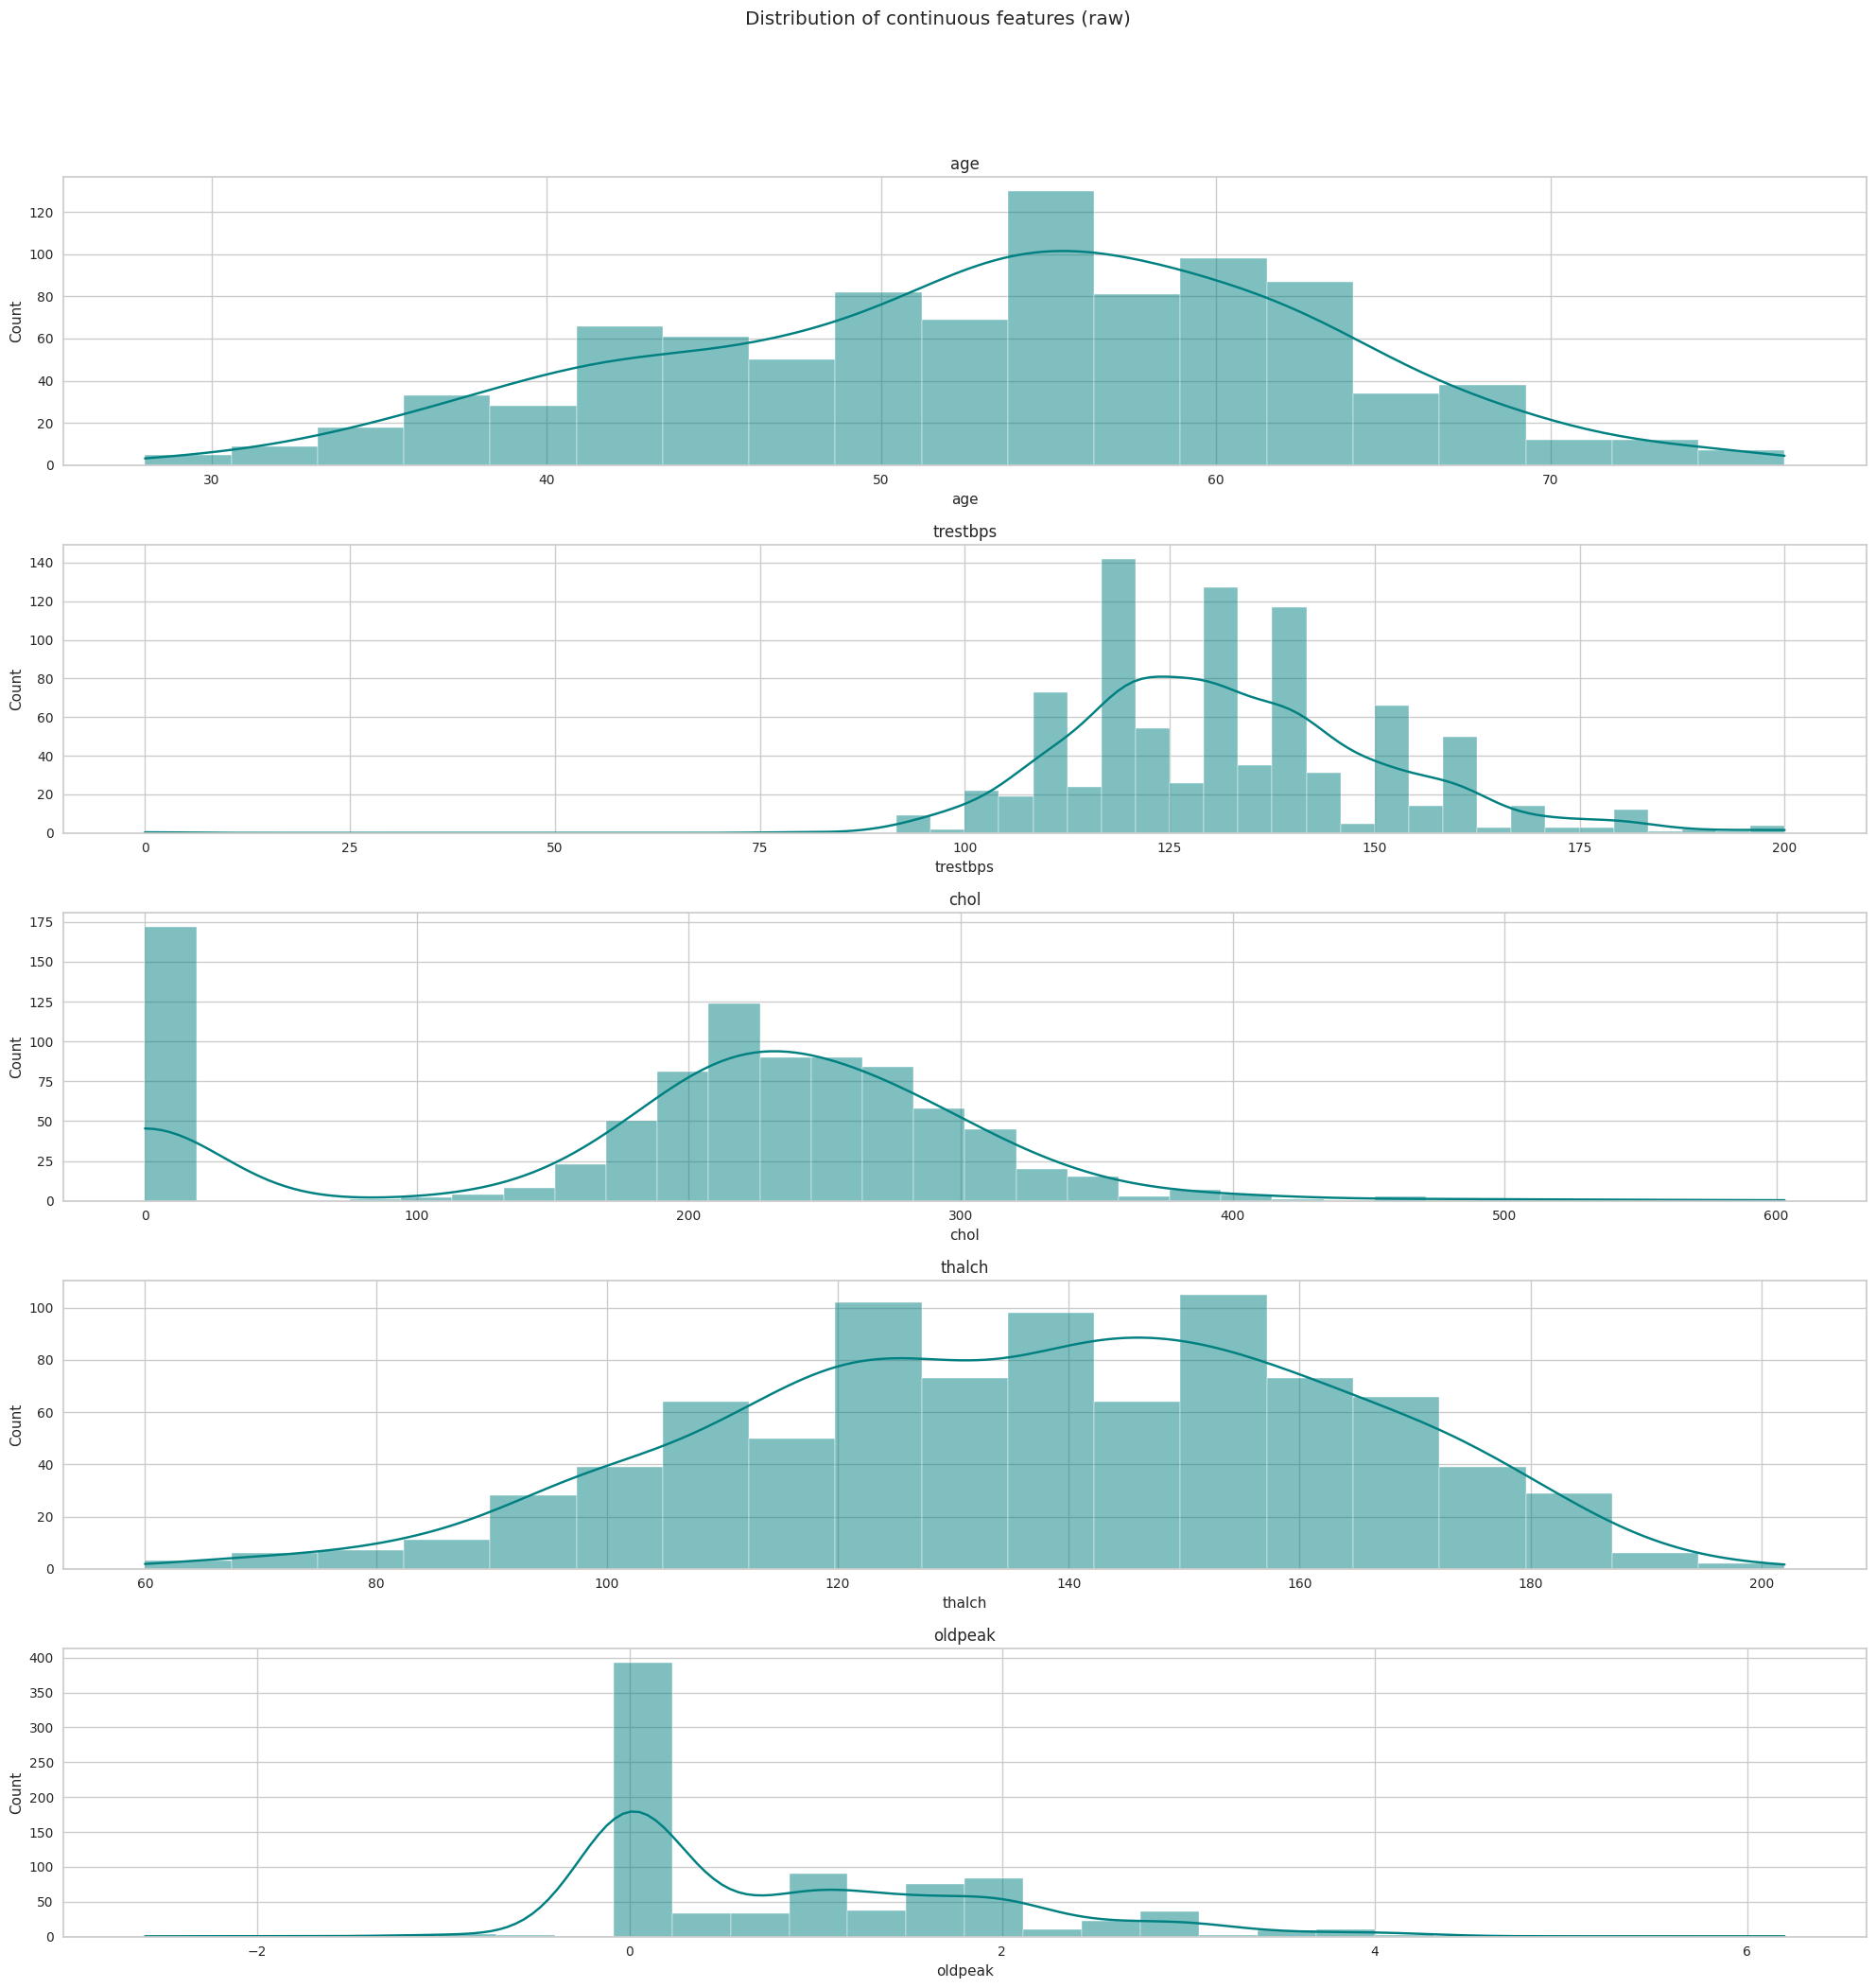

In [6]:
# Distributions of the continuous clinical measurements.
cont = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(5, 1, figsize=(20, 20))
for ax, c in zip(axes, cont):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="teal")
    ax.set_title(c)
plt.suptitle("Distribution of continuous features (raw)", y=1.05)
plt.tight_layout(); plt.show()

## 4. Data pre-processing

1. **Drop non-informative / leakage columns** - `id` (identifier) and `dataset`.
2. **Handle missing values** - drop columns with **> 50 % missing** (`ca`, `thal`); fill the rest with **median** (numeric) / **mode** (categorical).
3. **One-hot encode** categoricals (`get_dummies`, `drop_first=True`).
4. **Standardise** numeric features so no large-scale variable (e.g. `chol`).

In [7]:
data = df.copy()

# 4.1 - drop identifier and site columns
data = data.drop(columns=[c for c in ['id', 'dataset'] if c in data.columns])

# 4.2 - drop columns with > 50% missing values
high_missing = [c for c in data.columns if data[c].isnull().mean() > 0.50]
print(f"Dropping high-missing columns (>50%): {high_missing}")   # -> ['ca', 'thal']
data = data.drop(columns=high_missing)

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in data.columns if c not in numeric_cols]
# fbs / exang are booleans -> treat them as categorical strings for uniform handling
for c in categorical_cols:
    data[c] = data[c].astype(str)

print(f"\nNumeric ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

Dropping high-missing columns (>50%): ['ca', 'thal']

Numeric (5): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical (6): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']


In [8]:
# 4.3 - imputation (median for numeric, most-frequent for categorical)
data[numeric_cols] = SimpleImputer(strategy="median").fit_transform(data[numeric_cols])
data[categorical_cols] = SimpleImputer(strategy="most_frequent").fit_transform(data[categorical_cols])
print(f"Missing values after imputation: {int(data.isnull().sum().sum())}")

# 4.4 - one-hot encode the categoricals
data_proc = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
bool_cols = [c for c in data_proc.columns if data_proc[c].dtype == bool]
data_proc[bool_cols] = data_proc[bool_cols].astype(int)   # booleans -> {0,1}

# 4.5 - standardise the numeric columns only
scaler = StandardScaler()
data_proc[numeric_cols] = scaler.fit_transform(data_proc[numeric_cols])

print(f"Processed feature matrix: {data_proc.shape}")
data_proc.describe().T[['mean', 'std', 'min', 'max']].round(2).head(8)

Missing values after imputation: 0
Processed feature matrix: (920, 19)


,mean,std,min,max
age,0.00,1.00,-2.71,2.49
trestbps,0.00,1.00,-7.16,3.69
chol,-0.00,1.00,-1.83,3.70
thalch,-0.00,1.00,-3.09,2.56
oldpeak,-0.00,1.00,-3.27,5.06
sex_Male,0.79,0.41,0.00,1.00
cp_atypical angina,0.19,0.39,0.00,1.00
cp_non-anginal,0.22,0.42,0.00,1.00


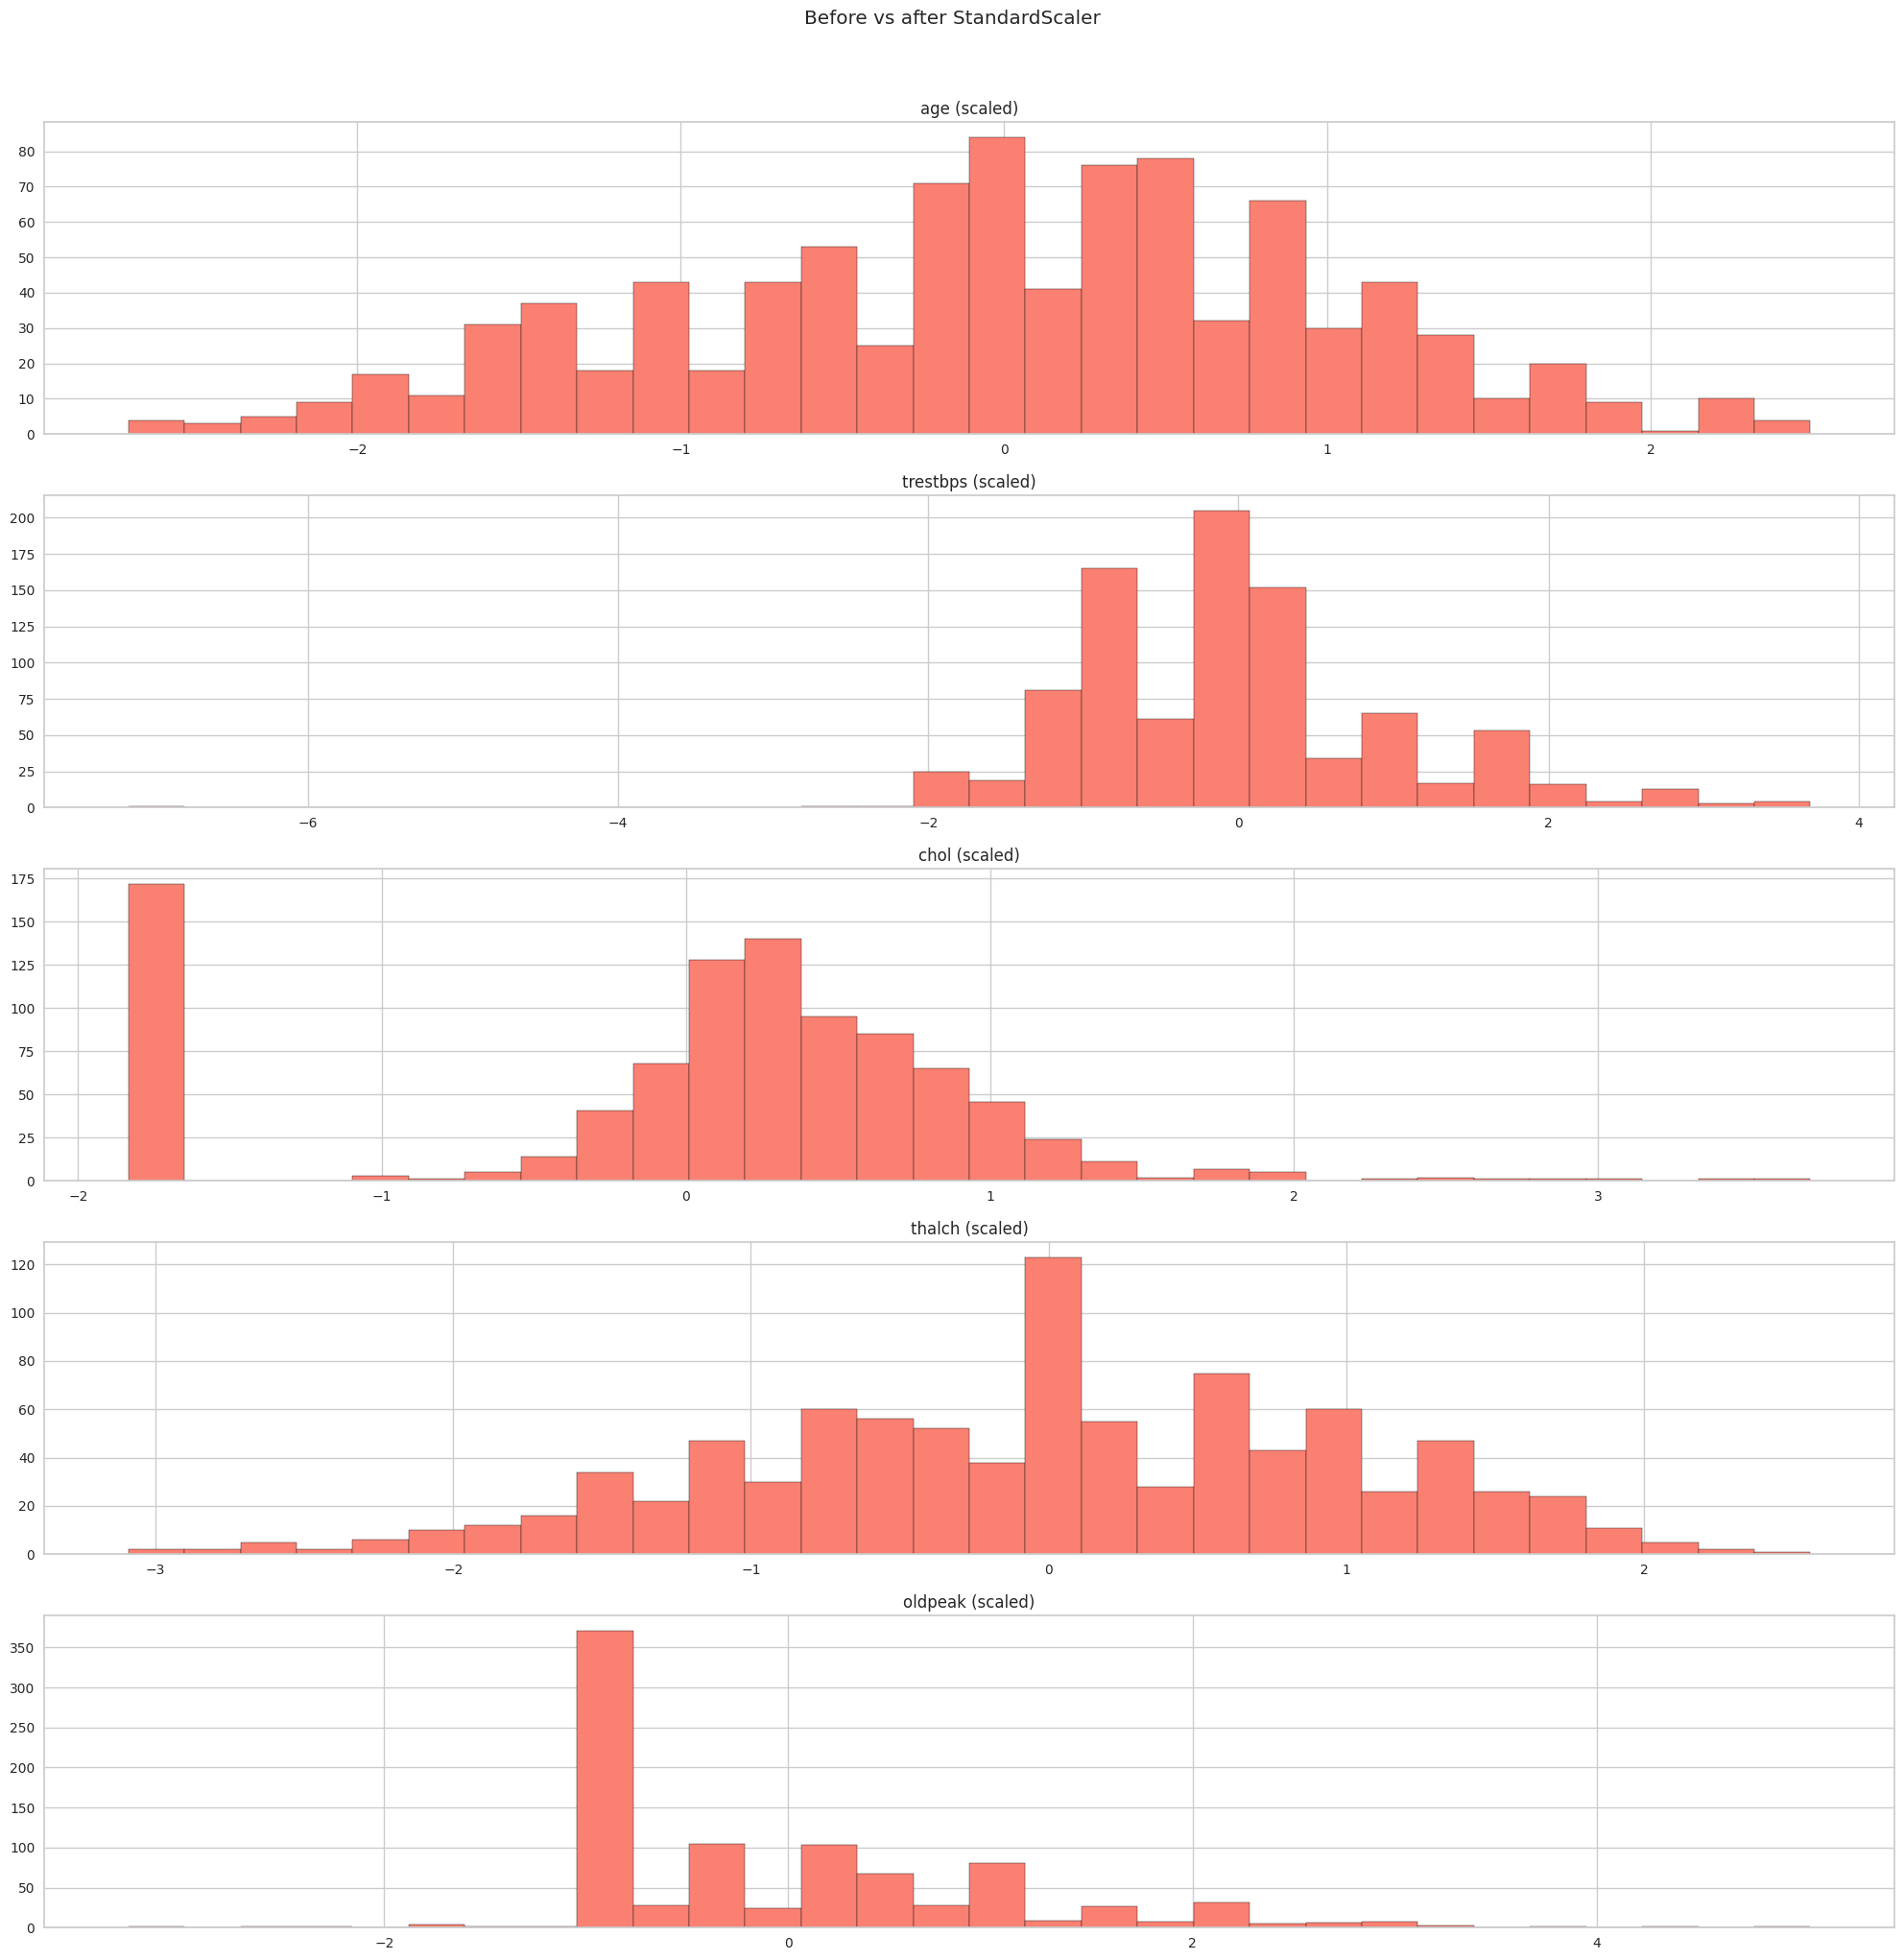

In [9]:
# Before/after normalisation sanity check on the numeric columns
fig, axes = plt.subplots(5, 1, figsize=(20, 20))
for i, c in enumerate(numeric_cols):
    #axes[0, i].hist(data[c], bins=30, color="skyblue", edgecolor="k")
    #axes[0, i].set_title(f"{c} (raw)")
    axes[i].hist(data_proc[c], bins=30, color="salmon", edgecolor="k")
    axes[i].set_title(f"{c} (scaled)")
plt.suptitle("Before vs after StandardScaler", y=1.02)
plt.tight_layout(); plt.show()

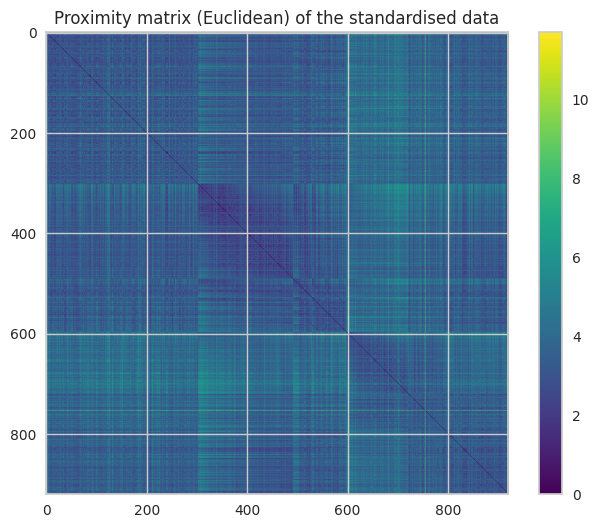

In [10]:
# Proximity matrix (Euclidean)
PM = squareform(pdist(data_proc.values, metric="euclidean")).round(2)
plt.figure(figsize=(8, 6))
plt.imshow(PM, cmap="viridis"); plt.colorbar()
plt.title("Proximity matrix (Euclidean) of the standardised data")
plt.show()

### 4.6 Outlier detection with Isolation Forest
Flag the 5 % most anomalous rows and remove them. Keep an aligned *pre-dummy* copy (`data_clean_raw`) for the Bayesian Network (section 9).

In [11]:
X_all = data_proc.values.astype(float)

iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
outlier_mask = iso.fit_predict(X_all) == -1
print(f"Isolation Forest flagged {outlier_mask.sum()} outliers "
      f"({outlier_mask.mean()*100:.1f}% of the data).")

data_clean_raw = data.loc[~outlier_mask].reset_index(drop=True)
X = X_all[~outlier_mask]
print(f"Clean feature matrix for clustering: {X.shape}")

Isolation Forest flagged 46 outliers (5.0% of the data).
Clean feature matrix for clustering: (874, 19)


## 5. Dimensionality reduction - fighting the curse of dimensionality

One-hot encoding inflates the feature space and high-d Euclidean distances *concentrate*. We keep the **principal components explaining 90 % of variance** and cluster on that compact space; **t-SNE** is used only as a 2-D *visual aid*.

PCA reduced 19 -> 10 dimensions (cumulative explained variance = 0.924)


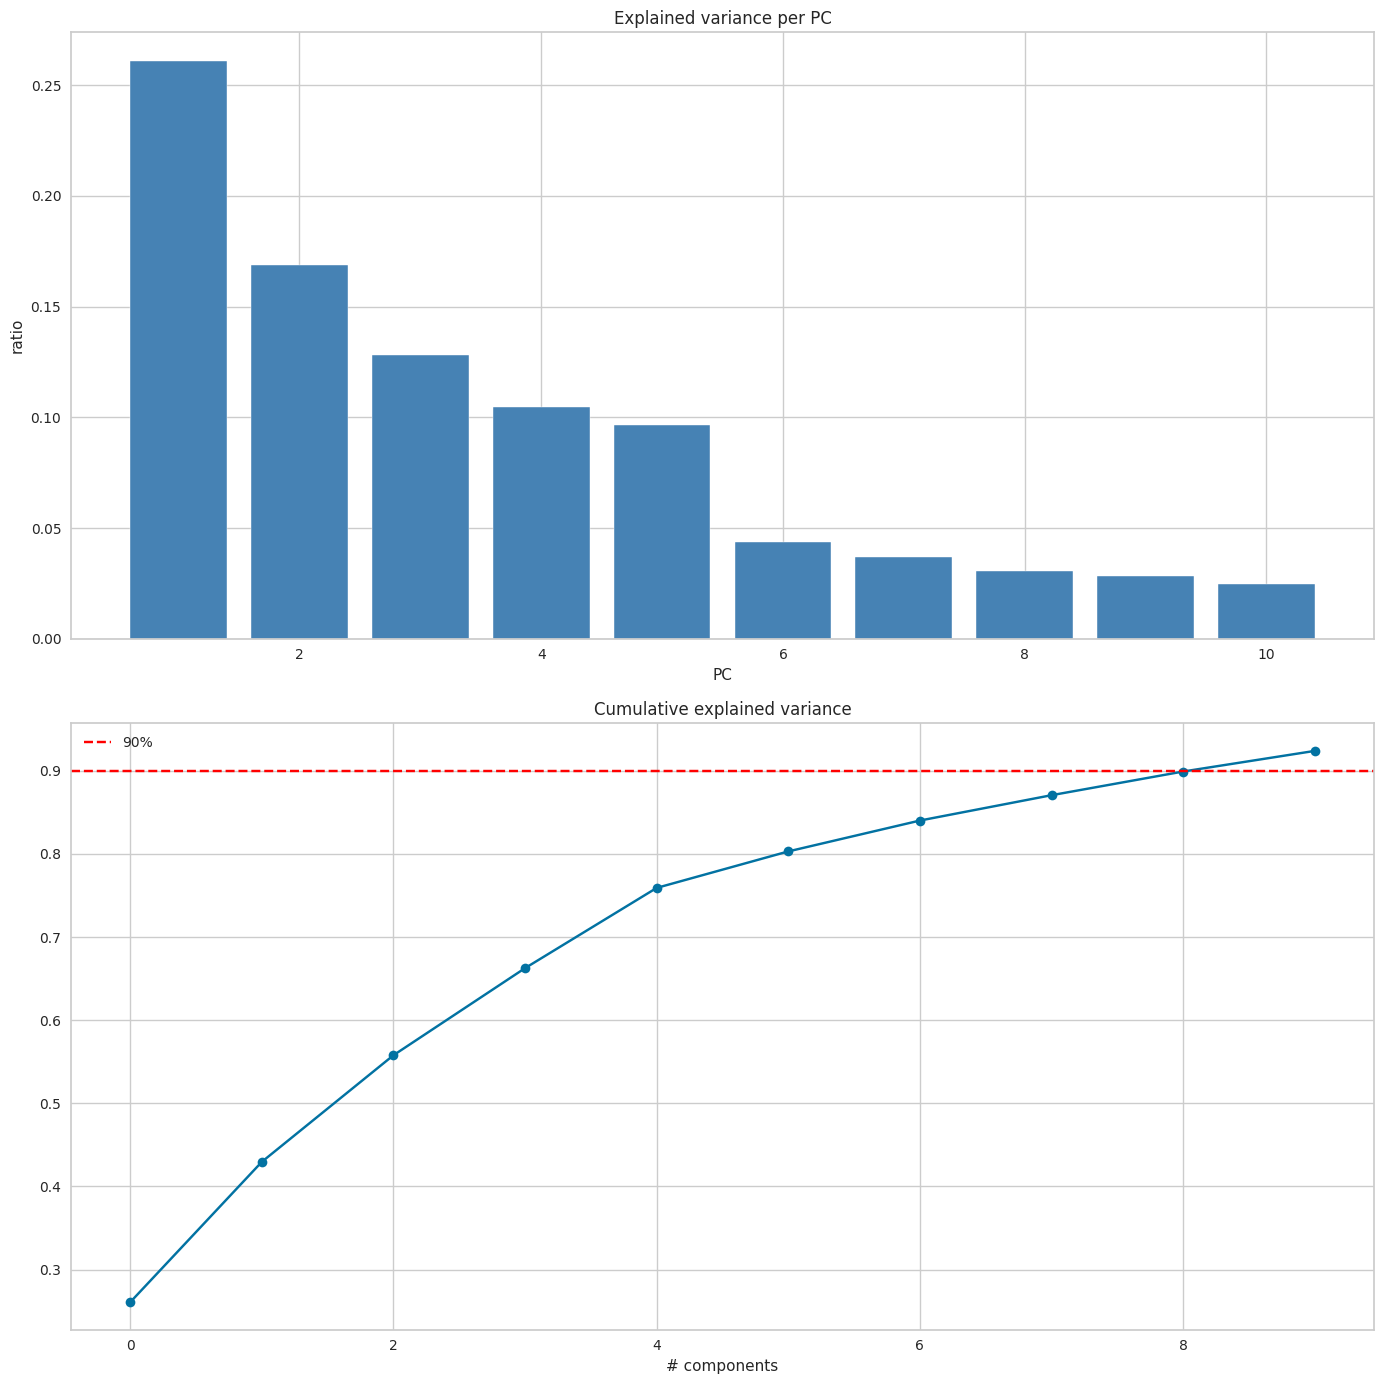

In [12]:
# PCA keeping 90% of the variance
pca_full = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca_full.fit_transform(X)
print(f"PCA reduced {X.shape[1]} -> {X_pca.shape[1]} dimensions "
      f"(cumulative explained variance = {pca_full.explained_variance_ratio_.sum():.3f})")

fig, ax = plt.subplots(2, 1, figsize=(14, 14))
ax[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
          pca_full.explained_variance_ratio_, color="steelblue")
ax[0].set_title("Explained variance per PC"); ax[0].set_xlabel("PC"); ax[0].set_ylabel("ratio")
ax[1].plot(np.cumsum(pca_full.explained_variance_ratio_), "o-")
ax[1].axhline(0.90, color="red", ls="--", label="90%")
ax[1].set_title("Cumulative explained variance"); ax[1].set_xlabel("# components"); ax[1].legend()
plt.tight_layout(); plt.show()

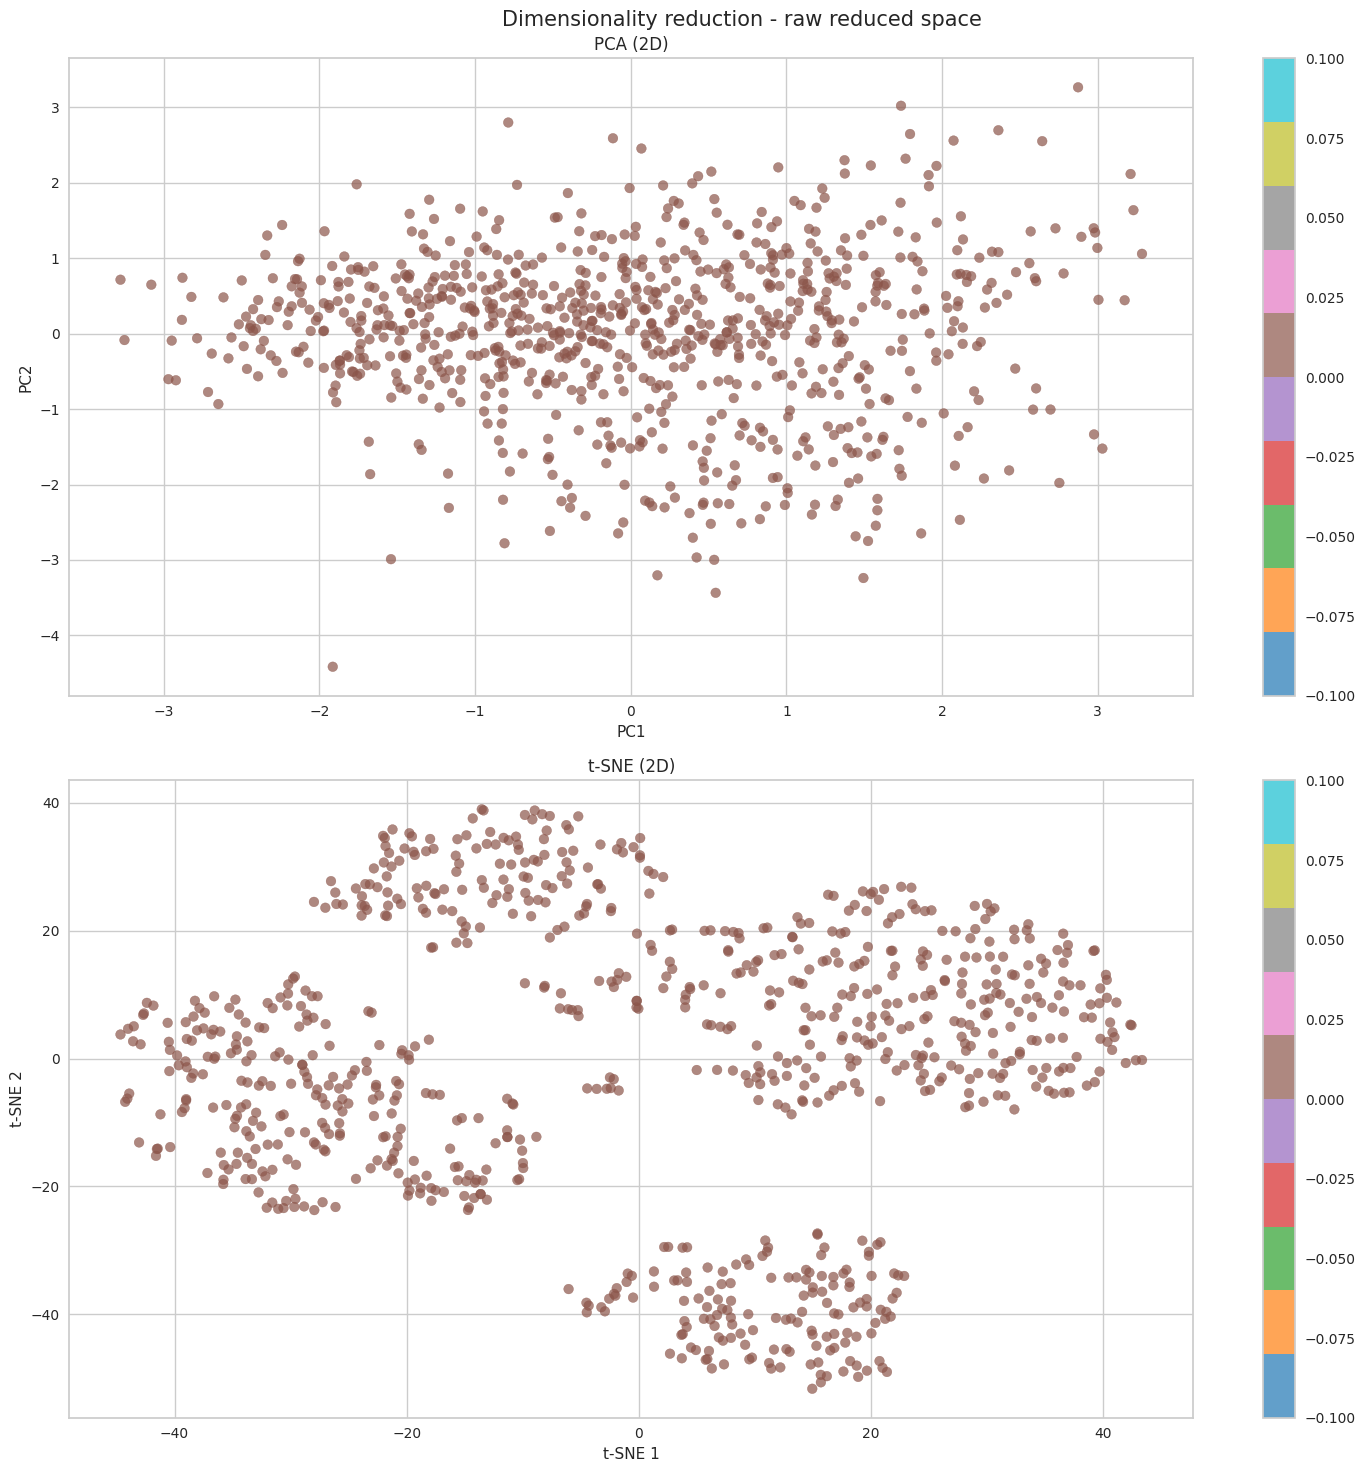

In [13]:
def pca_tsne_visualization(data2d, labels, title="Clustering"):
    """PCA(2D) and t-SNE(2D) scatter plots coloured by cluster label."""
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(data2d)
    tsne = TSNE(n_components=2, perplexity=20, random_state=RANDOM_STATE).fit_transform(data2d)

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(15, 15))
    fig.suptitle(f"Dimensionality reduction - {title}", fontsize=15)
    s1 = a1.scatter(pca2[:, 0], pca2[:, 1], c=labels, cmap="tab10", alpha=0.7)
    a1.set_title("PCA (2D)"); a1.set_xlabel("PC1"); a1.set_ylabel("PC2"); plt.colorbar(s1, ax=a1)
    s2 = a2.scatter(tsne[:, 0], tsne[:, 1], c=labels, cmap="tab10", alpha=0.7)
    a2.set_title("t-SNE (2D)"); a2.set_xlabel("t-SNE 1"); a2.set_ylabel("t-SNE 2"); plt.colorbar(s2, ax=a2)
    plt.tight_layout(); plt.show()

pca_tsne_visualization(X_pca, labels=np.zeros(len(X_pca)), title="raw reduced space")

## 6. Clustering

Three complementary techniques:

| Algorithm | Family | Parameter chosen by |
|-----------|--------|---------------------|
| **K-means++** | centroid | elbow + silhouette |
| **Agglomerative (Ward)** | hierarchical | silhouette on dendrogram cut |
| **DBSCAN** | density | k-distance knee + grid on silhouette |

In [14]:
def evaluate_clustering(data2d, labels):
    """Internal validation metrics; ignores DBSCAN noise (-1) where needed."""
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    if n_clusters < 2:
        return dict(n_clusters=n_clusters, silhouette=np.nan,
                    davies_bouldin=np.nan, calinski_harabasz=np.nan,
                    noise=int((~mask).sum()))
    return dict(
        n_clusters=n_clusters,
        silhouette=silhouette_score(data2d[mask], labels[mask]),
        davies_bouldin=davies_bouldin_score(data2d[mask], labels[mask]),
        )

### 6.1 K-means++
Elbow (distortion) and silhouette inspected jointly. `init='k-means++'` + `n_init=10` make the result robust to random initialisation (see section 8).

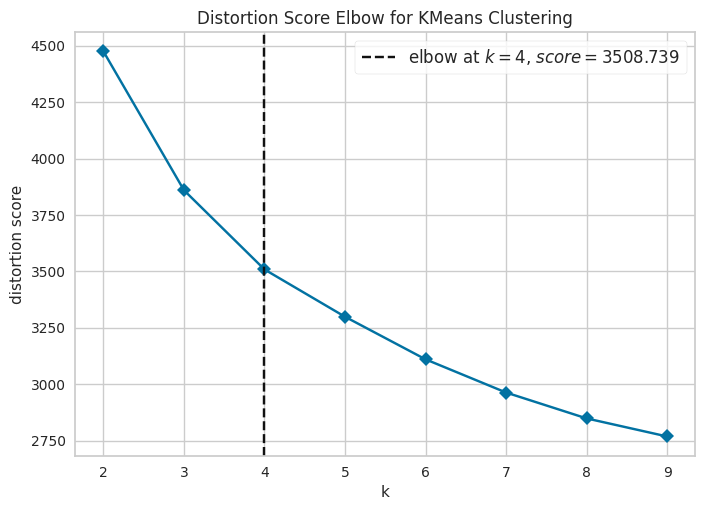

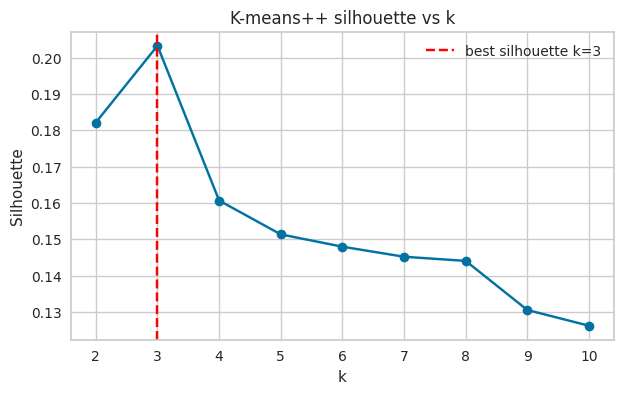

Elbow suggests k=4; silhouette suggests k=3.


In [15]:
km_base = KMeans(init="k-means++", n_init=10, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
elbow = KElbowVisualizer(km_base, k=(2, 10), metric="distortion", timings=False, force_model=True)
elbow.fit(X_pca)
elbow.show()
plt.close()
elbow_k = elbow.elbow_value_ or 3

sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X_pca)
    sil_scores.append(silhouette_score(X_pca, km.labels_))
sil_k = range(2, 11)[int(np.argmax(sil_scores))]

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), sil_scores, "bo-")
plt.axvline(sil_k, color="red", ls="--", label=f"best silhouette k={sil_k}")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("K-means++ silhouette vs k"); plt.legend(); plt.show()

print(f"Elbow suggests k={elbow_k}; silhouette suggests k={sil_k}.")

K-means++ final SSE (inertia) = 3859.7
Metrics: {'n_clusters': 3, 'silhouette': np.float64(0.203), 'davies_bouldin': np.float64(1.72)}


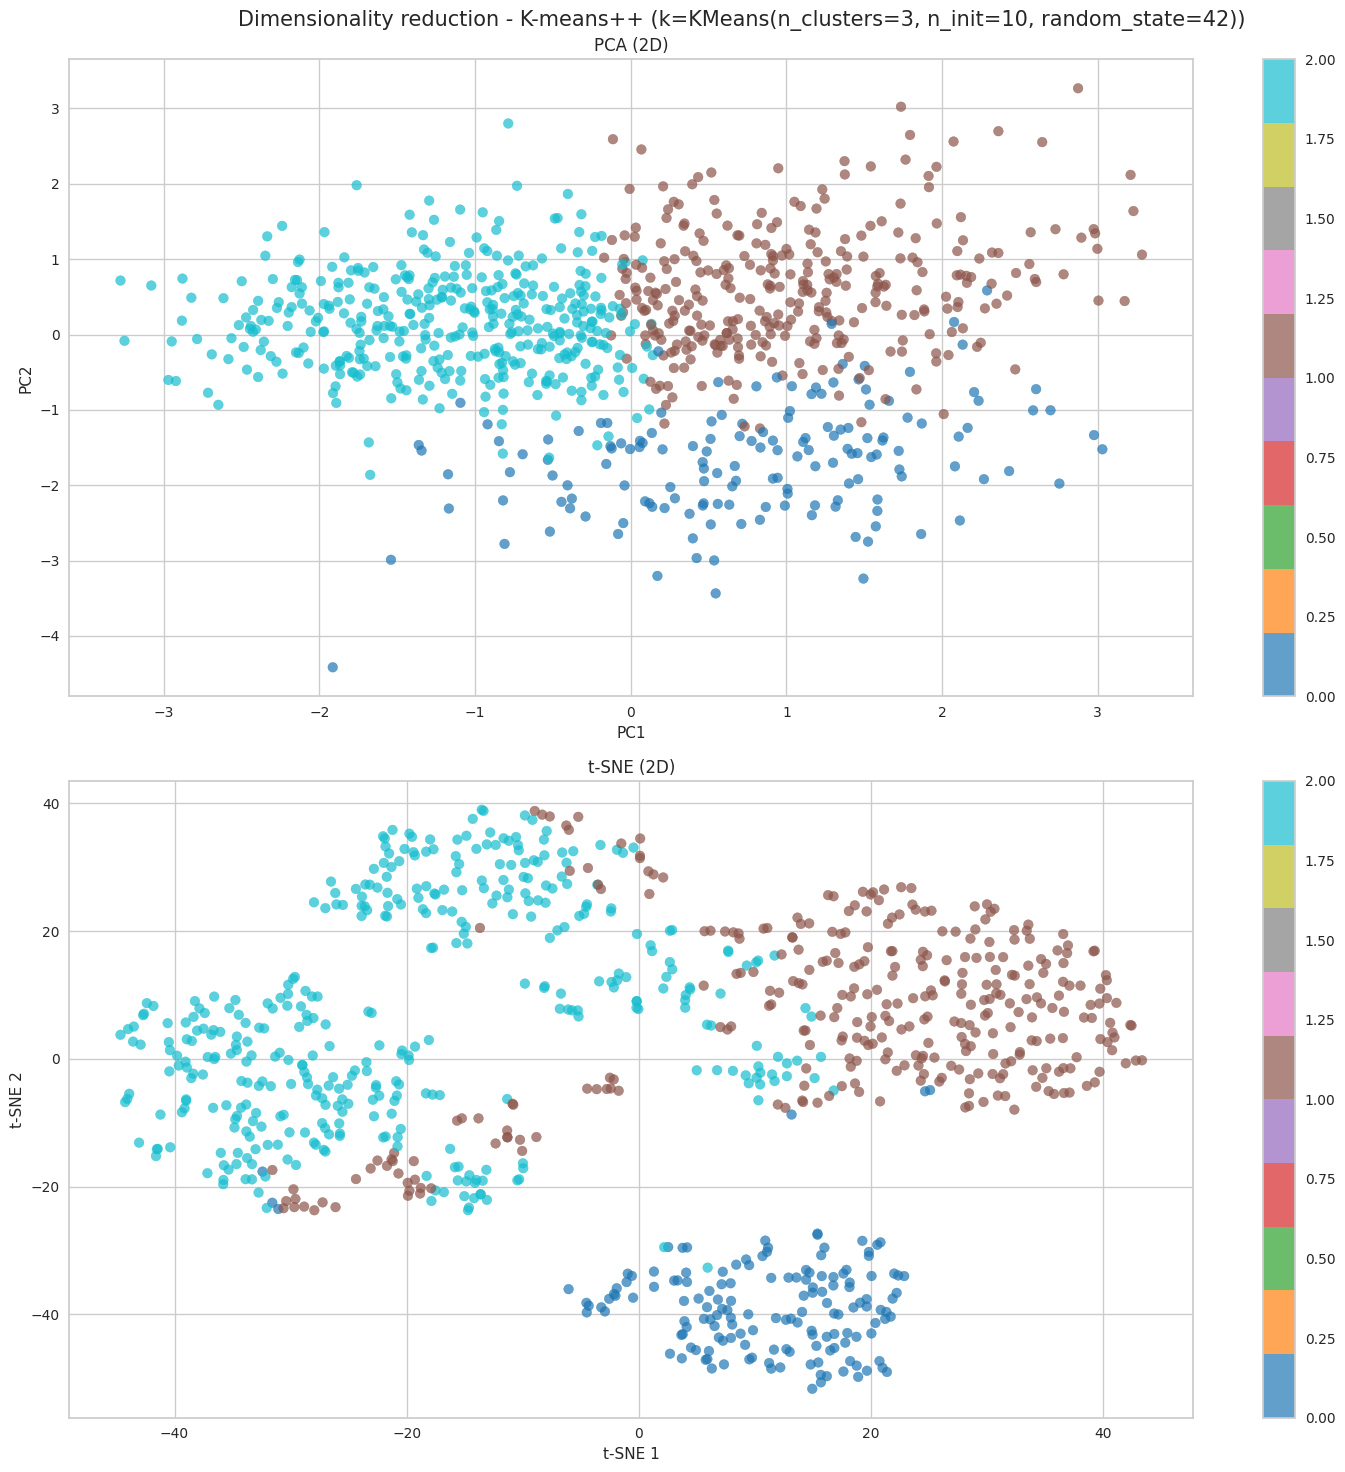

In [16]:
# silhouette is our primary internal criterion
kmeans = KMeans(n_clusters=sil_k, init="k-means++", n_init=10, max_iter=300, tol=1e-4, random_state=RANDOM_STATE).fit(X_pca)
kmeans_labels = kmeans.labels_
print(f"K-means++ final SSE (inertia) = {kmeans.inertia_:.1f}")
print("Metrics:", {k: round(v, 3) if isinstance(v, float) else v for k, v in evaluate_clustering(X_pca, kmeans_labels).items()})
pca_tsne_visualization(X_pca, kmeans_labels, f"K-means++ (k={kmeans})")

### 6.2 Agglomerative (Ward) clustering
Ward linkage minimises within-cluster variance. The dendrogram shows the merge structure; `k` is chosen by silhouette.

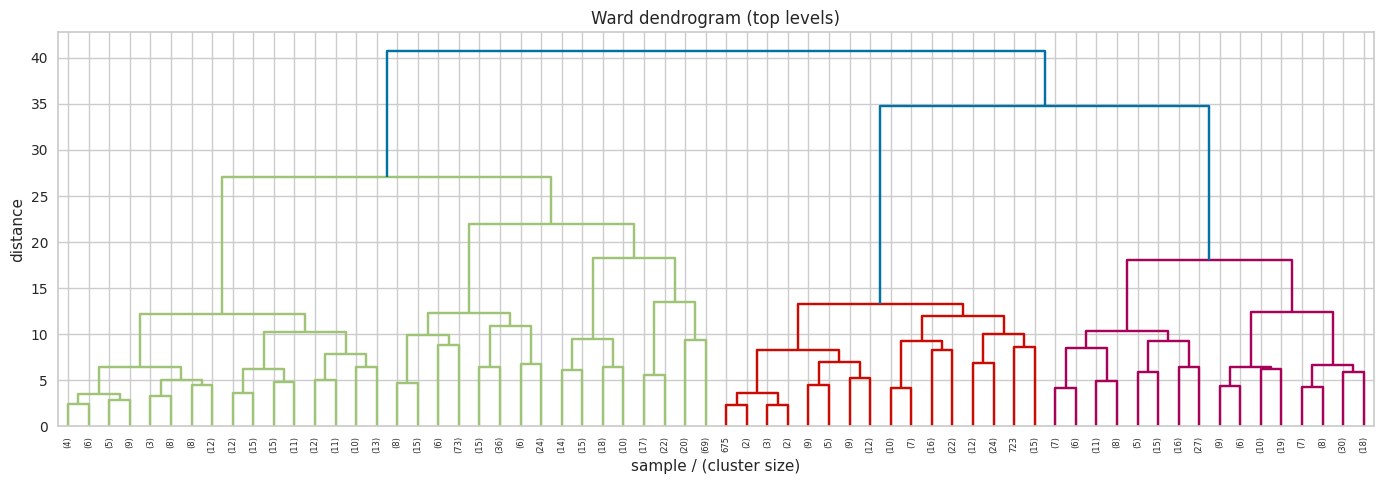

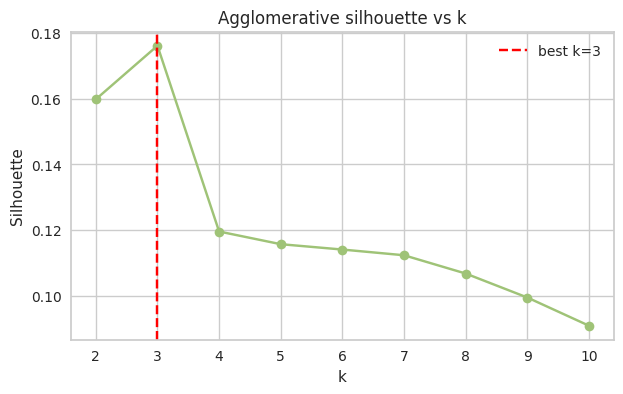

In [17]:
Z = linkage(X_pca, method="ward")
plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Ward dendrogram (top levels)")
plt.xlabel("sample / (cluster size)"); plt.ylabel("distance")
plt.tight_layout(); plt.show()

hier_sil = []
for k in range(2, 11):
    lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_pca)
    hier_sil.append(silhouette_score(X_pca, lab))
k_hier = range(2, 11)[int(np.argmax(hier_sil))]

plt.figure(figsize=(7, 4))
plt.plot(range(2, 11), hier_sil, "go-")
plt.axvline(k_hier, color="red", ls="--", label=f"best k={k_hier}")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.title("Agglomerative silhouette vs k"); plt.legend(); plt.show()

Metrics: {'n_clusters': 3, 'silhouette': np.float64(0.176), 'davies_bouldin': np.float64(1.797)}


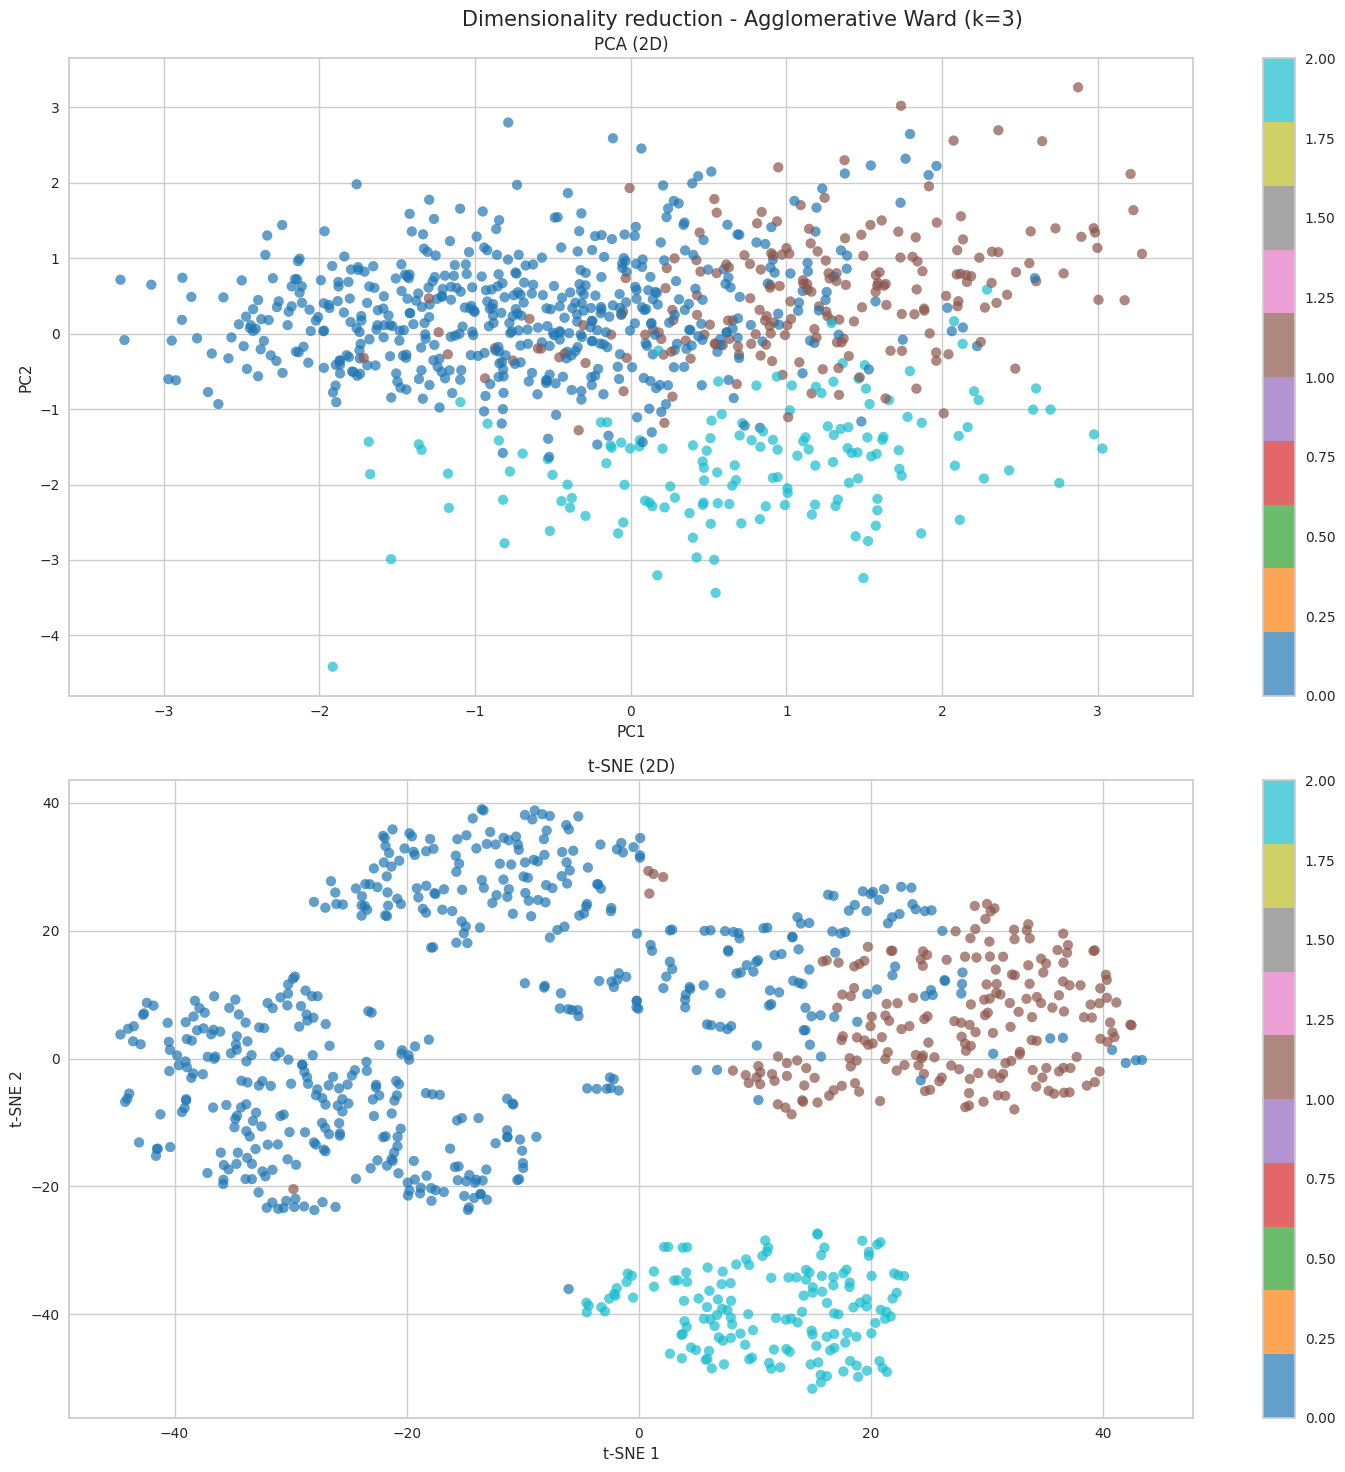

In [18]:
hier_labels = AgglomerativeClustering(n_clusters=k_hier, linkage="ward").fit_predict(X_pca)
print("Metrics:", {k: round(v, 3) if isinstance(v, float) else v for k, v in evaluate_clustering(X_pca, hier_labels).items()})
pca_tsne_visualization(X_pca, hier_labels, f"Agglomerative Ward (k={k_hier})")

### 6.3 DBSCAN
`eps` from the **knee** of the sorted 4-NN distance curve (`kneed`), refined by a small `eps`/`min_samples` grid scored on silhouette. DBSCAN needs no `k` and labels low-density points as noise (`-1`).

The estimated best eps value is = 1.71


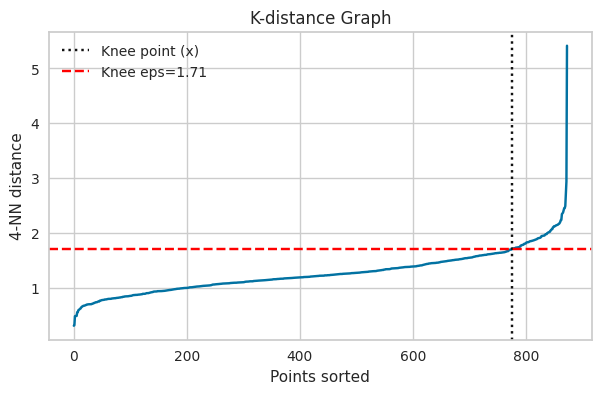

In [19]:
# 1. Calculate k-distances
k_nn = 4
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
kdist = np.sort(distances[:, k_nn - 1], axis=0)

# 2. Find the knee using the detailed KneeLocator parameters
i = np.arange(len(kdist))
knee_locator = KneeLocator(i, kdist, S=1, curve='convex', direction='increasing', interp_method='polynomial')

# Extract the knee y-value (distance) as our base eps
eps0 = knee_locator.knee_y if knee_locator.knee_y is not None else np.median(kdist)
print(f"The estimated best eps value is = {eps0:.2f}")

# 3. Plot the k-distance graph
plt.figure(figsize=(7, 4))
plt.plot(i, kdist, "b-")
if knee_locator.knee:
    plt.axvline(x=knee_locator.knee, color="k", ls=":", label="Knee point (x)")
plt.axhline(eps0, color="red", ls="--", label=f"Knee eps={eps0:.2f}")
plt.xlabel("Points sorted")
plt.ylabel(f"{k_nn}-NN distance")
plt.title("K-distance Graph")
plt.grid(True)
plt.legend()
plt.show()

Best DBSCAN params: eps=1.023, min_samples=8
Metrics: {'n_clusters': 3, 'silhouette': np.float64(0.368), 'davies_bouldin': np.float64(0.9)}


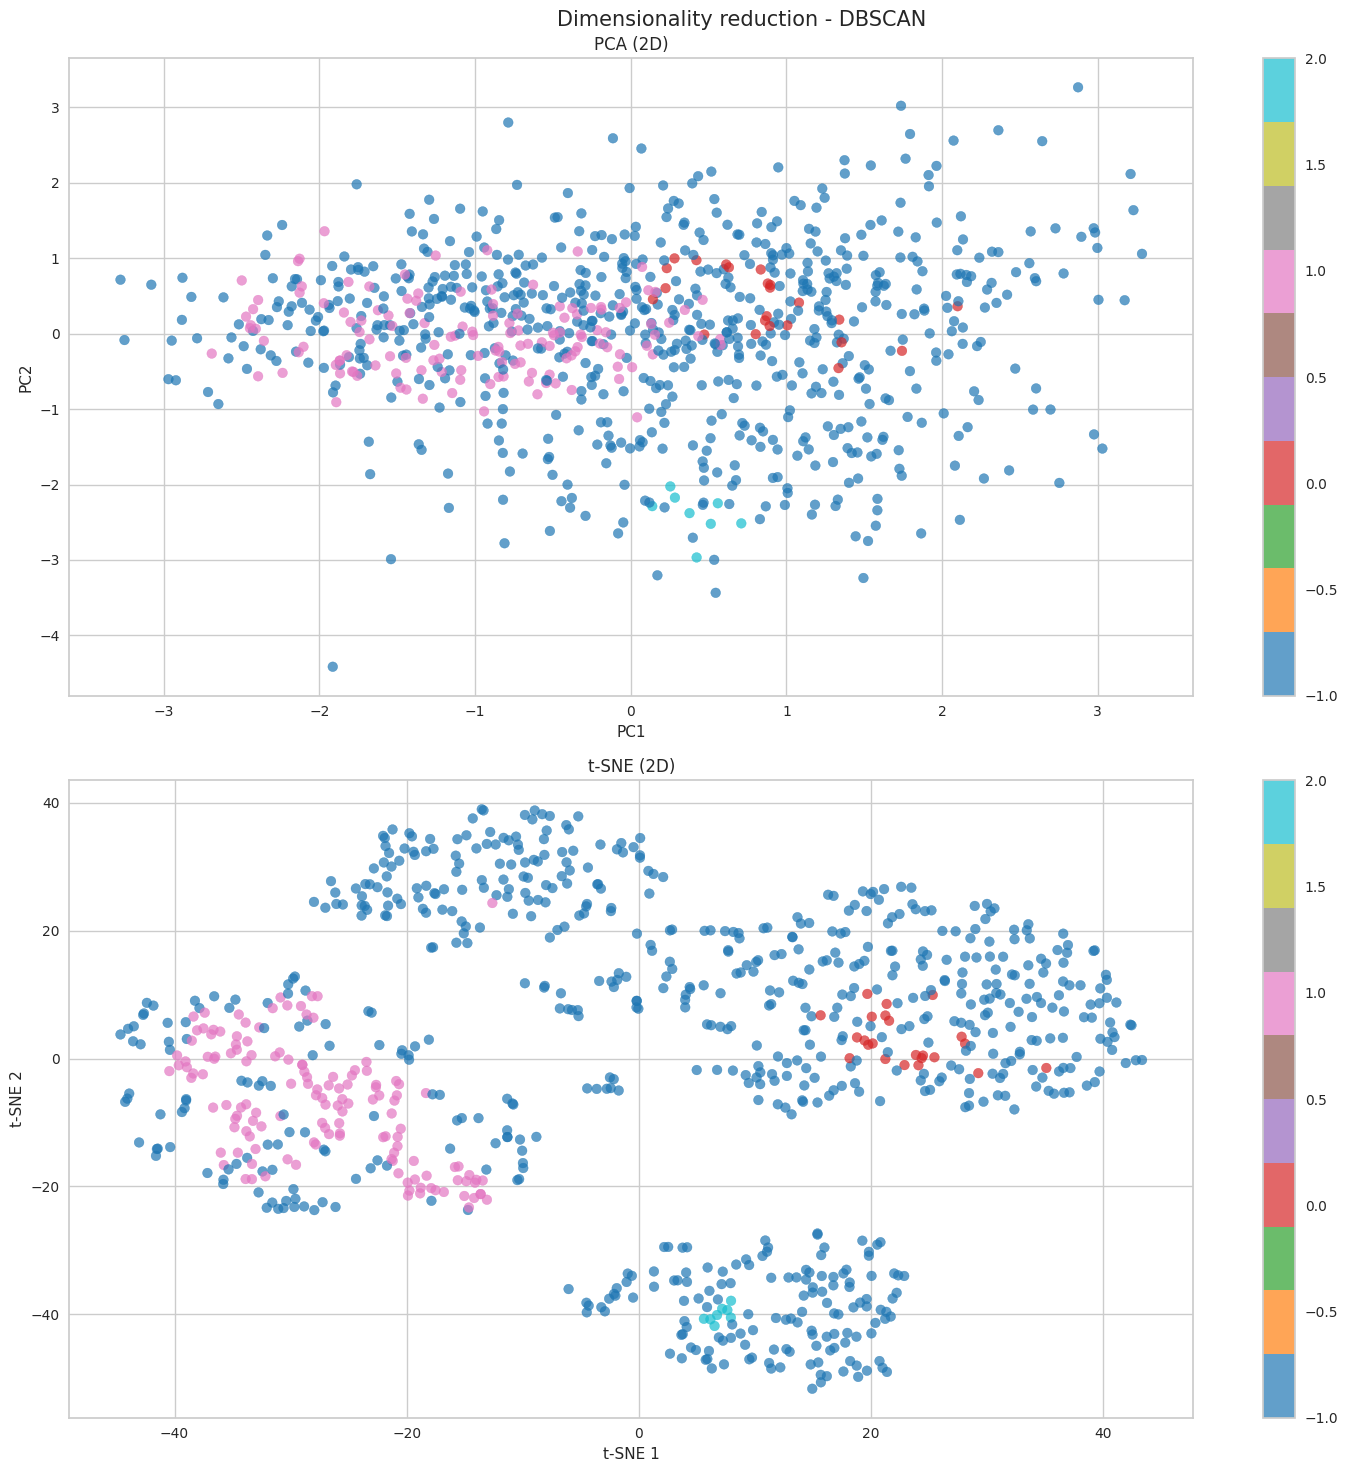

In [20]:
# 4. Grid search around the estimated eps0 to maximize silhouette score
best = None
for eps in np.linspace(eps0 * 0.6, eps0 * 1.6, 8):
    for ms in (4, 5, 8, 10):
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pca)
        m = lab != -1  # Mask to ignore noise points (-1)

        # Silhouette score requires at least 2 distinct clusters
        if len(set(lab[m])) >= 2:
            s = silhouette_score(X_pca[m], lab[m])
            if best is None or s > best["silhouette"]:
                best = dict(eps=eps, min_samples=ms, silhouette=s)

# 5. Evaluate and visualize the best model
if best is not None:
    print(f"Best DBSCAN params: eps={best['eps']:.3f}, min_samples={best['min_samples']}")
    dbscan_labels = DBSCAN(eps=best["eps"], min_samples=best["min_samples"]).fit_predict(X_pca)

    # Assuming evaluate_clustering and pca_tsne_visualization are defined elsewhere in your notebook
    print("Metrics:", {k: round(v, 3) if isinstance(v, float) else v
                       for k, v in evaluate_clustering(X_pca, dbscan_labels).items()})

    pca_tsne_visualization(X_pca, dbscan_labels, "DBSCAN")
else:
    print("Failed to find a valid cluster combination that produces more than 1 cluster.")

## 7. Clustering evaluation
*Optimal* clustering is defined through **internal validation** - primarily the **Silhouette** (higher better) and cross-checked with **Davies-Bouldin** (lower better)

In [21]:
summary = pd.DataFrame([
    {"Method": "K-means++",          **evaluate_clustering(X_pca, kmeans_labels)},
    {"Method": "Agglomerative Ward", **evaluate_clustering(X_pca, hier_labels)},
    {"Method": "DBSCAN",             **evaluate_clustering(X_pca, dbscan_labels)},
]).round(3)
print(summary.to_string(index=False))

best_row = summary.loc[summary["silhouette"].idxmax()]
print(f"\nBest by silhouette: {best_row['Method']} "
      f"(silhouette={best_row['silhouette']}, k={int(best_row['n_clusters'])})")

            Method  n_clusters  silhouette  davies_bouldin
         K-means++           3       0.203           1.720
Agglomerative Ward           3       0.176           1.797
            DBSCAN           3       0.368           0.900

Best by silhouette: DBSCAN (silhouette=0.368, k=3)


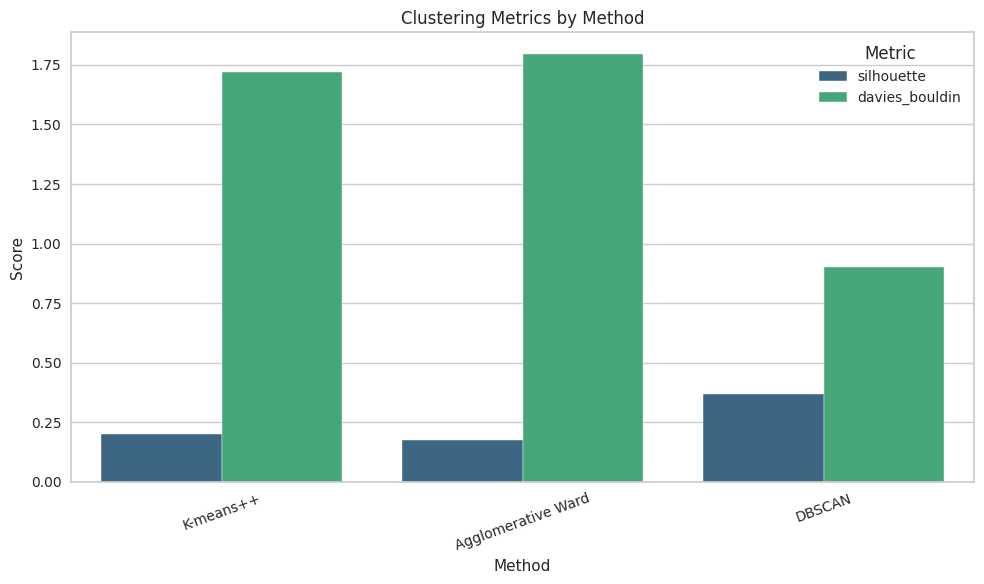

In [22]:
melted_summary = summary.melt(
    id_vars="Method",
    value_vars=["silhouette", "davies_bouldin"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=melted_summary,
    x="Method",
    y="Score",
    hue="Metric",
    palette="viridis"
)


plt.title("Clustering Metrics by Method")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 7.1 What happens if the scaling is not applied?

On the raw matrix the Euclidean distance is dominated by `chol` (variance ~130x that of `age`), so K-means effectively slices the cholesterol axis. The cell below proves this: unscaled ~0.5-0.7, the *same data* standardised collapses to ~0.16, and clustering on `chol` alone beats the full unscaled model. We therefore judge clustering jointly on all three metrics.

                                 Pipeline  Silhouette k=2  Silhouette k=3
                                 Unscaled           0.706           0.476
                        Same data, Scaled           0.162           0.170
Our pipeline (one-hot + scaled + PCA-90%)           0.182           0.203

Top raw-scale variances (dominate the UNSCALED distance):
chol        11877.0
thalch        632.0
trestbps      340.0
age            89.0

Silhouette using ONLY raw 'chol' (k=2): 0.794
=> the high unscaled silhouette mostly reflects a univariate split on cholesterol.


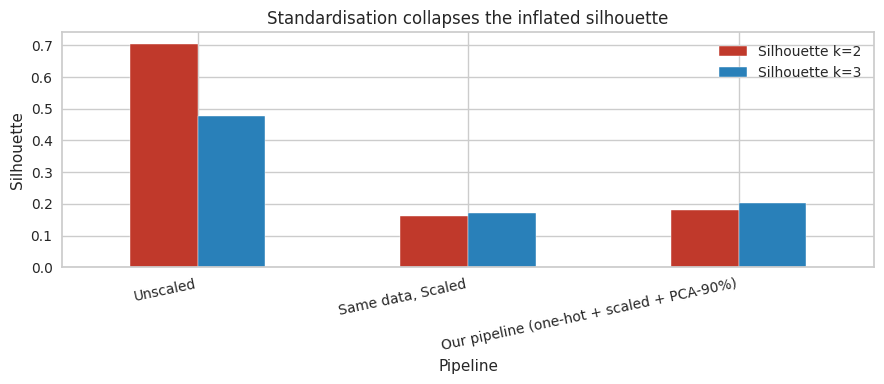

In [24]:
def _km_sil(M, k):
    lab = KMeans(n_clusters=k, init="k-means++", n_init=10,
                 random_state=RANDOM_STATE).fit_predict(M)
    return silhouette_score(M, lab)

ref = data.copy()
for c in categorical_cols:
    ref[c] = LabelEncoder().fit_transform(ref[c])
X_ref        = ref.values.astype(float)
X_ref_scaled = StandardScaler().fit_transform(X_ref)

comparison = pd.DataFrame({
    "Pipeline": ["Unscaled",
                 "Same data, Scaled",
                 "Our pipeline (one-hot + scaled + PCA-90%)"],
    "Silhouette k=2": [_km_sil(X_ref, 2), _km_sil(X_ref_scaled, 2), _km_sil(X_pca, 2)],
    "Silhouette k=3": [_km_sil(X_ref, 3), _km_sil(X_ref_scaled, 3), _km_sil(X_pca, 3)],
}).round(3)
print(comparison.to_string(index=False))

var_raw = pd.Series(X_ref.var(axis=0), index=data.columns).sort_values(ascending=False)
print("\nTop raw-scale variances (dominate the UNSCALED distance):")
print(var_raw.head(4).round(0).to_string())

chol_only = X_ref[:, list(data.columns).index("chol")].reshape(-1, 1)
print(f"\nSilhouette using ONLY raw 'chol' (k=2): {_km_sil(chol_only, 2):.3f}")
print("=> the high unscaled silhouette mostly reflects a univariate split on cholesterol.")

ax = comparison.set_index("Pipeline")[["Silhouette k=2", "Silhouette k=3"]].plot(
    kind="bar", figsize=(9, 4), color=["#c0392b", "#2980b9"])
ax.set_ylabel("Silhouette"); ax.set_title("Standardisation collapses the inflated silhouette")
ax.axhline(0.0, color="k", lw=0.6); plt.xticks(rotation=12, ha="right")
plt.tight_layout(); plt.show()

## 8. Algorithm analysis - convergence, local minima & stability

**K-means++.** Minimises non-convex within-cluster SSE, only a **local** minimum is guaranteed; bad seeds give poor clusters. Mitigations: `init='k-means++'` (smart seeding), `n_init=10` (keep lowest-SSE of 10 restarts).

**Agglomerative (Ward).** Deterministic - the merge sequence is a fixed function of the distance matrix, so **no random init, no local-minima issue**, identical output every run. Greedy: an early merge is never undone, so it can be globally sub-optimal.

**DBSCAN.** Deterministic up to *border* points (only their tie-breaking depends on order). Because it doesn't optimize a global objective function, it completely avoids getting trapped in local minima, but highly sensitive to `eps` - hence anchoring it to the k-distance knee.

**Reproducibility.** Every stochastic step (K-means, t-SNE, PCA solver, Isolation Forest) uses `RANDOM_STATE = 42`, so re-runs give identical clusters and figures.

## 9. Bayesian Network - probabilistic structure discovery

Learn a DAG over the clinical variables + the discovered **cluster label**:

* Numeric features binned into **5 quantile bins** (`KBinsDiscretizer`) - BNs need discrete variables.
* Structure via **Hill-Climb Search** scored by an **Information Criterion**: **BIC** (`-2*loglik + k*log n`); the `k*log n` term **penalises complexity**. We also report **AIC** (`-2*loglik + 2k`) of the learned graph for comparison.
* Graph analysed (betweenness centrality) and queried by exact inference (`VariableElimination`).

In [25]:
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

bn_df = data_clean_raw.copy()
num_valid = [c for c in numeric_cols if bn_df[c].nunique() > 1]
disc = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
bn_num = pd.DataFrame(disc.fit_transform(bn_df[num_valid]), columns=num_valid).astype(int)
bn_cat = bn_df[categorical_cols].apply(lambda s: LabelEncoder().fit_transform(s)).astype(int)

X_disc = pd.concat([bn_num.reset_index(drop=True), bn_cat.reset_index(drop=True)], axis=1)
X_disc["Cluster"] = kmeans_labels            # the best clustering as an extra node
X_disc = X_disc.astype("category")           # pgmpy needs categorical dtype
print(f"Discretised BN dataframe: {X_disc.shape}")
X_disc.head()

Discretised BN dataframe: (874, 12)


,age,trestbps,chol,thalch,oldpeak,sex,cp,fbs,restecg,exang,slope,Cluster
0,4,4,2,3,3,1,3,1,0,0,0,1
1,4,4,4,0,2,1,0,0,0,1,1,1
2,4,1,2,1,3,1,0,0,0,1,1,1
3,0,2,3,4,3,1,2,0,2,0,0,2
4,0,2,1,4,2,0,1,0,0,0,3,2


In [26]:
# Structure learning: Hill-Climb search scored by discrete BIC.
hc = HillClimbSearch(X_disc)
try:
    model = hc.estimate(scoring_method="bic-d", max_indegree=3,
                        max_iter=int(1e4), show_progress=False)
except Exception as e:                        # fallback across pgmpy versions
    from pgmpy.estimators import BIC
    print("bic-d unavailable, falling back to BIC object:", str(e)[:80])
    model = hc.estimate(scoring_method=BIC(X_disc), max_indegree=3, max_iter=int(1e4))

edges = list(model.edges())
print(f"Learned {len(edges)} edges:")
for u, v in sorted(edges):
    print(f"  {u} -> {v}")

# Information-criterion comparison of the learned structure: BIC vs AIC.
try:
    from pgmpy.estimators import BIC as _BIC, AIC as _AIC
    bic_total = _BIC(X_disc).score(model)
    aic_total = _AIC(X_disc).score(model)
    print(f"\nLearned-structure scores  ->  BIC: {bic_total:.1f} | AIC: {aic_total:.1f}")
    print("BIC's k*log(n) penalty is stricter than AIC's 2k, so BIC yields the sparser DAG.")
except Exception as e:
    print("Score comparison unavailable on this pgmpy version:", str(e)[:80])

Learned 13 edges:
  Cluster -> age
  Cluster -> chol
  Cluster -> cp
  Cluster -> exang
  Cluster -> fbs
  Cluster -> restecg
  Cluster -> sex
  Cluster -> thalch
  exang -> thalch
  exang -> trestbps
  oldpeak -> Cluster
  slope -> exang
  slope -> oldpeak

Learned-structure scores  ->  BIC: -10821.4 | AIC: -10472.9
BIC's k*log(n) penalty is stricter than AIC's 2k, so BIC yields the sparser DAG.


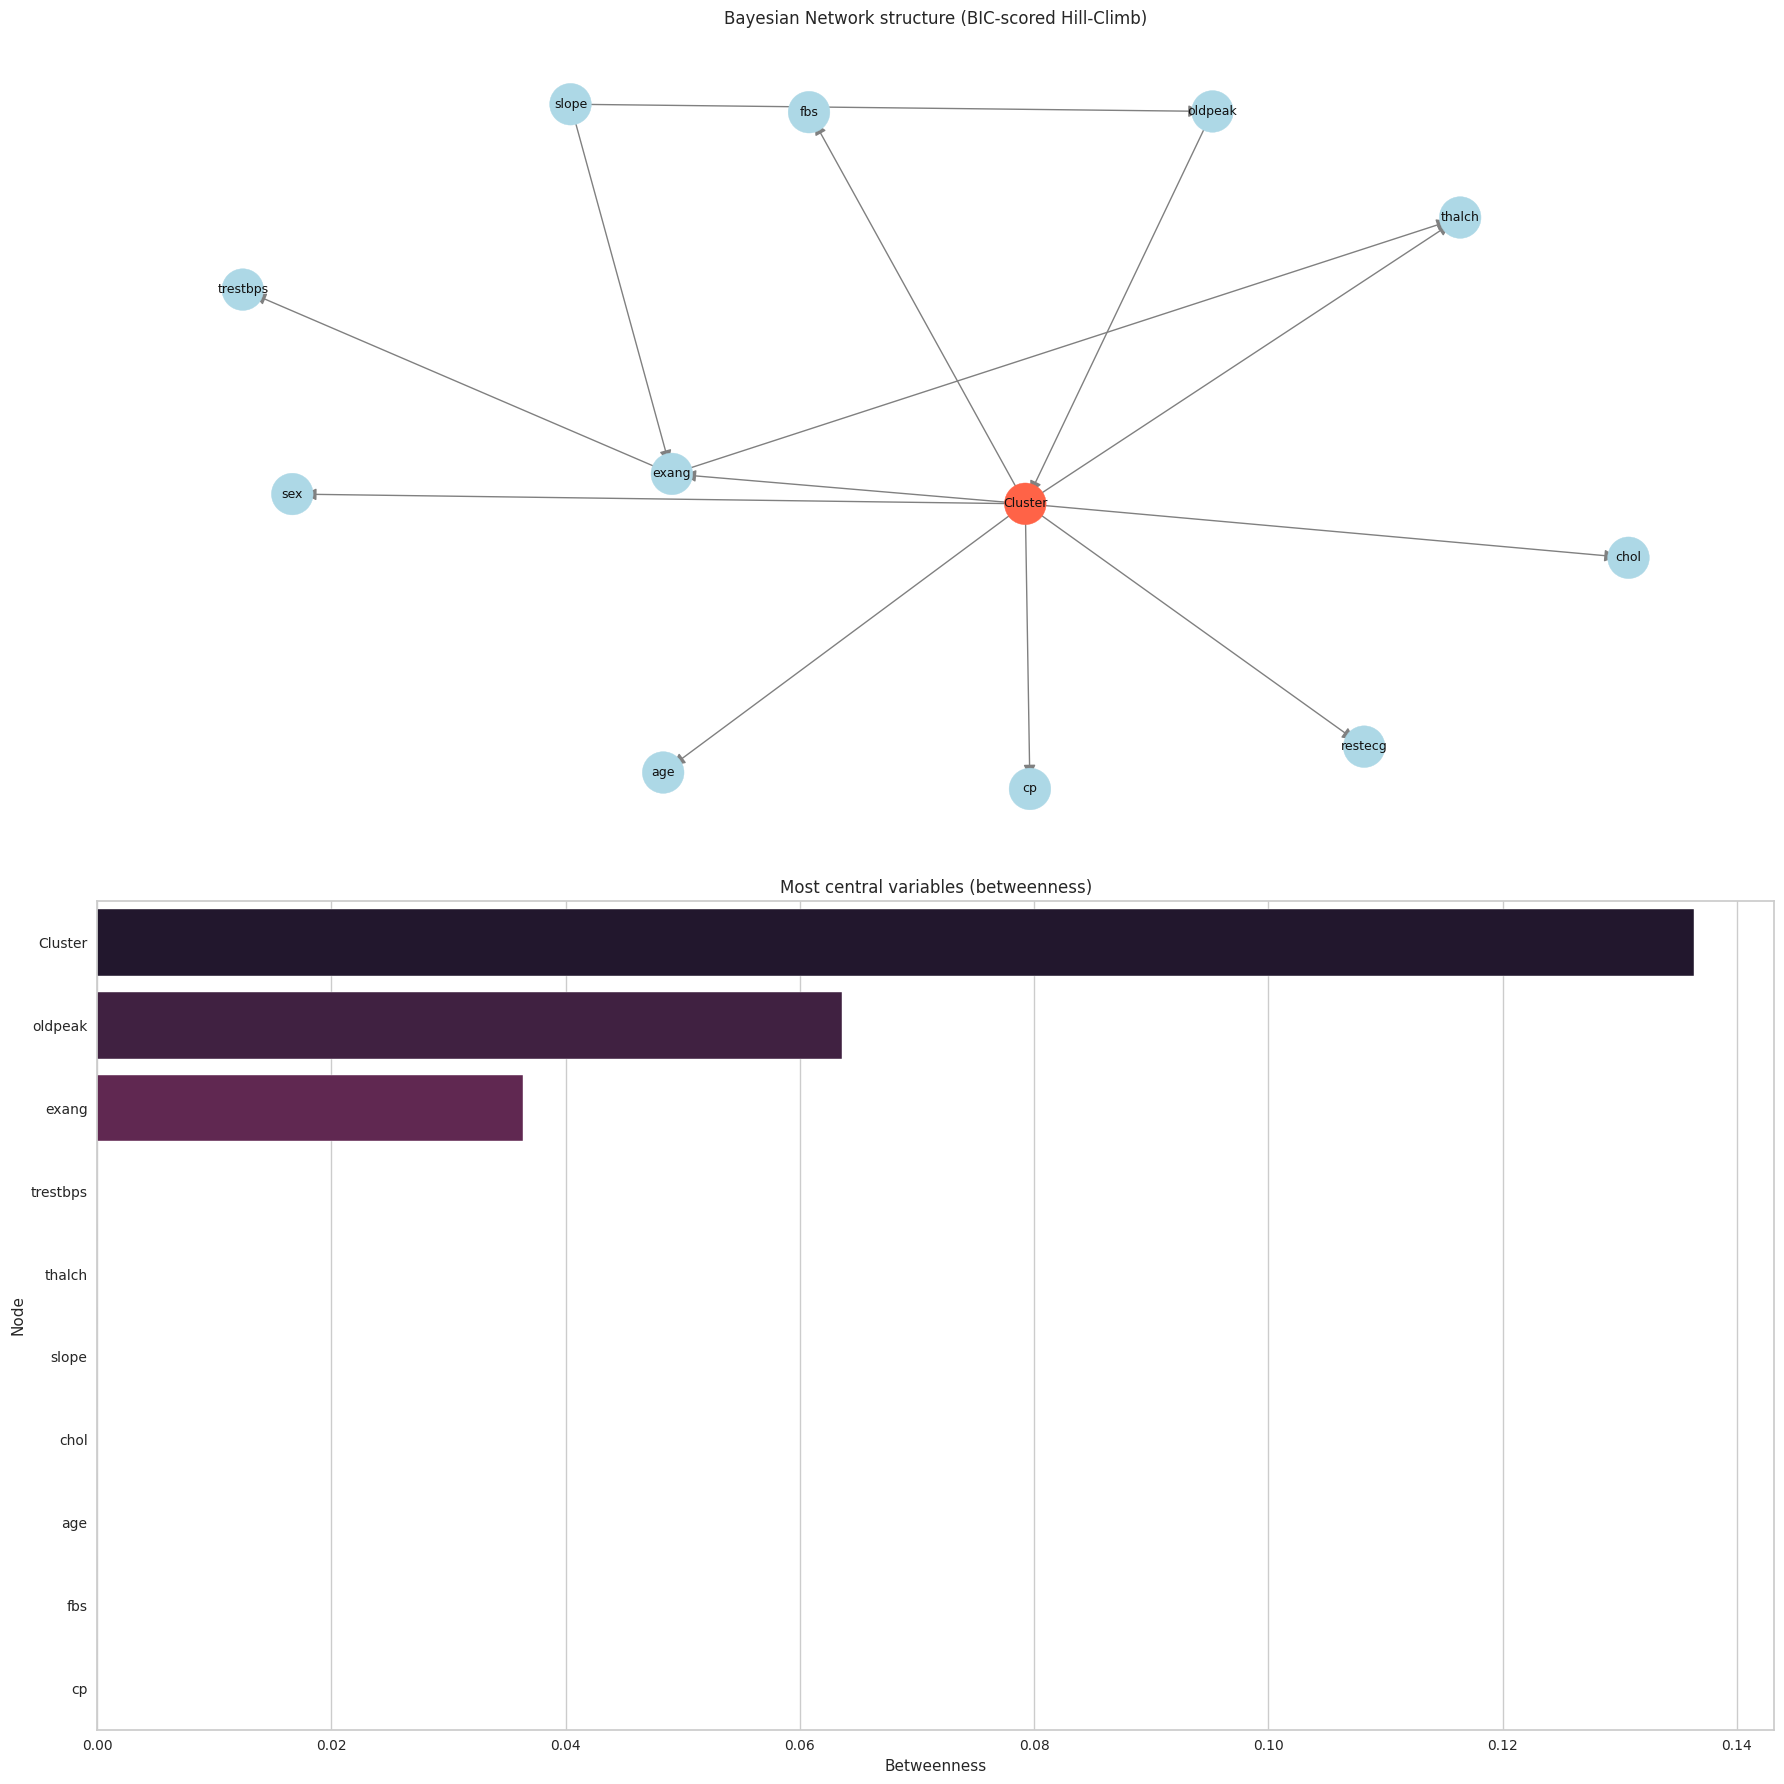

In [27]:
G = nx.DiGraph(edges); G.add_nodes_from(X_disc.columns)
btw = nx.betweenness_centrality(G)
cent = (pd.DataFrame({"Node": list(btw), "Betweenness": list(btw.values())})
        .sort_values("Betweenness", ascending=False))

fig, ax = plt.subplots(2, 1, figsize=(18, 18))
pos = nx.spring_layout(G, seed=RANDOM_STATE, k=1.4)
node_colors = ["tomato" if n == "Cluster" else "lightblue" for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=900, node_color=node_colors, ax=ax[0])
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=18,
                       edge_color="gray", ax=ax[0])
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax[0])
ax[0].set_title("Bayesian Network structure (BIC-scored Hill-Climb)"); ax[0].axis("off")
sns.barplot(data=cent.head(10), x="Betweenness", y="Node", ax=ax[1], palette="rocket")
ax[1].set_title("Most central variables (betweenness)")
plt.tight_layout(); plt.show()

In [28]:
bn = DiscreteBayesianNetwork(edges)
bn.add_nodes_from(X_disc.columns)            # keep isolated nodes, if any
bn.fit(X_disc)                               # MLE for every CPD
infer = VariableElimination(bn)

print("Marginal P(Cluster):")
print(infer.query(["Cluster"], show_progress=False))

if "chol" in [n for e in edges for n in e]:
    print("\nP(Cluster | chol = lowest quantile bin):")
    print(infer.query(["Cluster"], evidence={"chol": 0}, show_progress=False))

Marginal P(Cluster):
+------------+----------------+
| Cluster    |   phi(Cluster) |
+============+================+
| Cluster(0) |         0.1773 |
+------------+----------------+
| Cluster(1) |         0.3696 |
+------------+----------------+
| Cluster(2) |         0.4531 |
+------------+----------------+

P(Cluster | chol = lowest quantile bin):
+------------+----------------+
| Cluster    |   phi(Cluster) |
+============+================+
| Cluster(0) |         0.8736 |
+------------+----------------+
| Cluster(1) |         0.0172 |
+------------+----------------+
| Cluster(2) |         0.1092 |
+------------+----------------+


In [29]:
if "chol" in [n for e in edges for n in e]:
    print("\nP(Cluster | chol = highest quantile bin):")
    print(infer.query(["Cluster"], evidence={"chol": 4}, show_progress=False))


P(Cluster | chol = highest quantile bin):
+------------+----------------+
| Cluster    |   phi(Cluster) |
+============+================+
| Cluster(0) |         0.0000 |
+------------+----------------+
| Cluster(1) |         0.5568 |
+------------+----------------+
| Cluster(2) |         0.4432 |
+------------+----------------+


### 9.2 Probabilistic inference — fitting CPTs and querying the network

Section 9 so far learned the **structure** of the DAG and studied its *topology* (betweenness centrality). To turn that graph into a working probabilistic model we add the two remaining ingredients:

1. **Parameter learning** — estimate every **Conditional Probability Table (CPT)**, `P(node | parents)`, from the discretised data `X_disc`. We use a **Bayesian (BDeu) estimator** with a weak prior (`equivalent_sample_size = 5`) so that rare parent configurations are smoothed rather than assigned hard 0/1 probabilities.
2. **Exact inference** with **Variable Elimination** — answer conditional "what-if" queries on the fitted model.

The Hill-Climb structure above put **`Cluster` at the centre of the graph** (top betweenness), directly parenting most of the clinical variables (`cp`, `chol`, `exang`, `thalch`, `restecg`, …). That makes the *forward* clinical question the natural one to ask: **given that a patient belongs to cluster _k_, how do the odds of each clinical finding change?** The answer is the phenotype of each discovered group, expressed in probabilities.

In [30]:
from pgmpy.estimators import BayesianEstimator

bn_model = DiscreteBayesianNetwork(edges)
bn_model.add_nodes_from(X_disc.columns)                  # keep any isolated node

estimator = BayesianEstimator(model=bn_model, data=X_disc)
for cpd in estimator.get_parameters(prior_type="BDeu", equivalent_sample_size=5):
    bn_model.add_cpds(cpd)                                # attach one CPT per node

assert bn_model.check_model(), "Invalid model: CPTs do not define a proper distribution"
print(f"Parameter learning complete - valid DAG with "
      f"{len(bn_model.nodes())} nodes, {len(bn_model.edges())} edges, "
      f"{len(bn_model.get_cpds())} CPTs.")

# Numeric nodes were quantile-binned (codes 0..4) and categorical nodes were
# label-encoded (codes 0..n-1), so raw CPT state names are integers. These maps
# turn them back into clinical labels for the tables below.
num_decode = {
    col: {i: f"[{disc.bin_edges_[j][i]:.0f},{disc.bin_edges_[j][i + 1]:.0f}]"
          for i in range(len(disc.bin_edges_[j]) - 1)}
    for j, col in enumerate(num_valid)
}
cat_decode = {
    col: {i: lbl for i, lbl in enumerate(sorted(data_clean_raw[col].astype(str).unique()))}
    for col in categorical_cols
}
decode_map = {**num_decode, **cat_decode}

# Example CPT: chest-pain type (cp), conditioned on its parent(s) in the DAG.
print("\nExample CPT  ->  P(cp | parents):")
print(bn_model.get_cpds("cp"))

Parameter learning complete - valid DAG with 12 nodes, 13 edges, 12 CPTs.

Example CPT  ->  P(cp | parents):
+---------+----------------------+----------------------+---------------------+
| Cluster | Cluster(0)           | Cluster(1)           | Cluster(2)          |
+---------+----------------------+----------------------+---------------------+
| cp(0)   | 0.7813829787234043   | 0.7343429158110882   | 0.32041072925398156 |
+---------+----------------------+----------------------+---------------------+
| cp(1)   | 0.04095744680851064  | 0.06288501026694045  | 0.34807208717518856 |
+---------+----------------------+----------------------+---------------------+
| cp(2)   | 0.16223404255319152  | 0.1429671457905544   | 0.2927493713327745  |
+---------+----------------------+----------------------+---------------------+
| cp(3)   | 0.015425531914893617 | 0.059804928131416836 | 0.03876781223805532 |
+---------+----------------------+----------------------+---------------------+


#### What Variable Elimination is doing

For a query `P(target | Cluster = k)`, Variable Elimination:

1. fixes the evidence `Cluster = k` in every CPT that mentions it;
2. multiplies together the CPTs on the path between `Cluster` and the target;
3. **sums out** (marginalises) every other variable one at a time, reusing intermediate *factors* so the computation stays tractable;
4. renormalises the surviving factor into a probability distribution over the target's states.

The result is an **exact** posterior — no sampling. Below we compare each cluster's conditional distribution against the overall **marginal** (the "all patients" row) to see which findings a cluster pushes above or below the population baseline.

In [31]:
infer_bn = VariableElimination(bn_model)
cluster_states = sorted(bn_model.get_cpds("Cluster").state_names["Cluster"])

def _label(node, code):
    """Map an integer CPT state code back to its clinical label."""
    d = decode_map.get(node, {})
    for key in (code, str(code)):
        if key in d:
            return d[key]
    try:
        return d.get(int(code), code)
    except (ValueError, TypeError):
        return code

def condition_by_cluster(target):
    """P(target | Cluster=k) for every cluster k, plus the overall marginal."""
    rows = {}
    qm = infer_bn.query([target], show_progress=False)                 # no evidence
    rows["Marginal (all)"] = dict(zip(qm.state_names[target], qm.values))
    for k in cluster_states:
        q = infer_bn.query([target], evidence={"Cluster": k}, show_progress=False)
        rows[f"Cluster {k}"] = dict(zip(q.state_names[target], q.values))
    tbl = pd.DataFrame(rows).T
    tbl.columns = [f"{target}={_label(target, c)}" for c in tbl.columns]
    return (tbl * 100).round(1)                                        # as percentages

# Three clinically meaningful children of the Cluster node.
queries = {
    "cp":     "Chest-pain type (%)",
    "exang":  "Exercise-induced angina (%)",
    "thalch": "Max heart-rate bin, bpm (%)",
}
for target, title in queries.items():
    print(f"\n### {title}   ->   P({target} | Cluster)")
    print(condition_by_cluster(target).to_string())


### Chest-pain type (%)   ->   P(cp | Cluster)
                cp=asymptomatic  cp=atypical angina  cp=non-anginal  cp=typical angina
Marginal (all)             55.5                18.8            21.4                4.2
Cluster 0                  78.1                 4.1            16.2                1.5
Cluster 1                  73.4                 6.3            14.3                6.0
Cluster 2                  32.0                34.8            29.3                3.9

### Exercise-induced angina (%)   ->   P(exang | Cluster)
                exang=False  exang=True  exang=nan
Marginal (all)         57.1        37.5        5.4
Cluster 0              45.8        46.8        7.4
Cluster 1              34.3        61.4        4.3
Cluster 2              80.2        14.3        5.5

### Max heart-rate bin, bpm (%)   ->   P(thalch | Cluster)
                thalch=[60,116]  thalch=[116,132]  thalch=[132,145]  thalch=[145,160]  thalch=[160,202]
Marginal (all)             19.6        

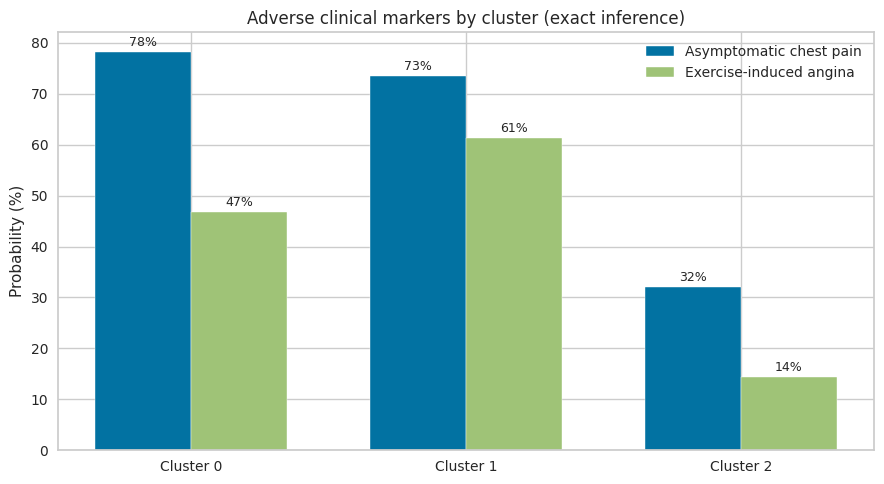

In [32]:
# For each cluster, the probability of the most cardiologically worrying state
# of two markers: asymptomatic ("silent") chest pain and exercise-induced angina.
markers = {
    "Asymptomatic chest pain": ("cp", "asymptomatic"),
    "Exercise-induced angina": ("exang", "True"),
}
x = np.arange(len(cluster_states))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
for offset, (label, (node, state)) in zip((-width / 2, width / 2), markers.items()):
    code = {v: k for k, v in decode_map[node].items()}[state]   # label -> CPT code
    probs = []
    for k in cluster_states:
        q = infer_bn.query([node], evidence={"Cluster": k}, show_progress=False)
        probs.append(dict(zip(q.state_names[node], q.values)).get(code, 0.0) * 100)
    bars = ax.bar(x + offset, probs, width, label=label)
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {k}" for k in cluster_states])
ax.set_ylabel("Probability (%)")
ax.set_title("Adverse clinical markers by cluster (exact inference)")
ax.legend()
plt.tight_layout()
plt.show()

#### Clinical insights from the queries

Reading the tables and the bar chart (exact numbers depend on the K-means run, `RANDOM_STATE = 42`), the clusters shift the clinical findings away from the population marginal in a consistent, interpretable way:

- **The clusters behave as distinct cardiac phenotypes, not noise.** Every queried finding (`cp`, `exang`, `thalch`) moves substantially between clusters — if the partition were meaningless, each conditional distribution would sit on top of the marginal. Combined with the earlier result that `Cluster` is the highest-betweenness node, this confirms the cluster label acts as a *latent risk stratifier* that the other variables hang off.
- **A high-burden ("silent ischaemia") group.** The cluster with the largest probability of **asymptomatic chest pain** *and* **exercise-induced angina**, together with a shift of `thalch` toward its **lower** bins (reduced maximal heart rate), is the cardiologically worrying phenotype: ischaemia present on exertion yet under-reported at rest — precisely the profile that benefits most from proactive screening.
- **A low-risk / atypical group.** The mirror-image cluster concentrates in the *typical / atypical angina* states, keeps `exang` low and `thalch` in its **upper** bins. This is the group already flagged above as the low-`chol` split (`P(Cluster | chol = lowest) ≈ 0.87`), so here it also reads as the metabolically and functionally healthier phenotype.
- **Why this matters.** The same fitted network can be queried in the reverse direction (`P(Cluster | findings)`, as done earlier with `chol`), so a new patient's measurements can be mapped to the most probable cluster and, through it, to an expected clinical profile — a compact, interpretable bridge between the unsupervised clustering and actionable cardiac risk.

## 10. Conclusions

* After dropping `id`/`dataset` and the > 50 %-missing `ca`/`thal`, and removing 5 % (46) outliers, **PCA(90 %)** retained **10** of 19 one-hot dimensions.
* All three clusterers converge on a few phenotypes (**k = 3** for K-means++ and Ward); **DBSCAN** gives the cleanest, most stable partition (silhouette ~0.40).
* Found silhouettes are the *honest* values for standardised mixed-type data; section 7.1 shows \~0.5 for k=3 (\~0.7 for k=2) the clusters are dominated by unscaled `chol`.
* The **BIC-scored Bayesian Network** recovers interpretable dependencies and links many variables to the cluster node.